# AgriTrust-MF: Constraint-Preserving QAOA for Interference-Aware Multi-Flow WSN Routing

**Revised conference experimental notebook — corrected methodology and clean rerun.**

## Research question
A 150-node smart-agriculture WSN carries several simultaneous source-to-sink flows. Each flow has multiple **topology-feasible candidate paths**. Selecting one path changes the cost of other flows through **cross-flow wireless interference and congestion**, so the task is to choose **one path per flow jointly**.

## Quantum formulation
- **Path-level one-hot encoding:** one block per flow.
- **W/Dicke-1 initialization:** exactly one route is active in each flow block initially.
- **Block-wise ring-product XY mixer:** every pair unitary preserves Hamming weight, so the one-route-per-flow constraint is preserved by construction.
- **Penalty-X QAOA baseline:** `|+>` initialization + X mixer + quadratic exactly-one penalties.
- **CVaR is an optimizer objective, not a quantum gate.** Its value is tested rather than assumed.

## Corrections in this revision
1. Primary solution-quality gap is the **most-probable feasible state gap**, not the optimistic best-of-2048-shots gap.
2. Every 9/12/16/20-qubit subset of one seed uses **one fixed normalization fitted on the full 5-flow × 5-path master set**.
3. Penalty-X sensitivity is tested at multipliers **1, 2, 4**; the pre-declared primary multiplier remains 2.
4. A full 9-qubit ablation tests **p = 1,2,3** and **α = 0.10,0.25,0.50,1.00** (`α=1` = expectation) for both XY and X families.
5. Main 9-qubit QAOA uses **3 deterministic optimizer restarts**. Large statevector scaling uses 1 restart for tractability and records that fact explicitly.
6. Wilcoxon comparisons include **Holm-Bonferroni correction**.
7. The paper gets a **compact logical circuit** plus a separate full executable RZ/RZZ/RXX/RYY circuit.
8. Noise sensitivity is evaluated on **all 20 seeds**, reusing the exact optimized parameters from the main 9-qubit experiment.
9. Heavy-hex resource reporting derives the actual coupling-map size rather than hard-coding it.

## Fixed 20 experimental seeds
`11, 23, 37, 53, 71, 89, 107, 131, 157, 179, 211, 233, 269, 293, 317, 347, 379, 419, 457, 491`

They are unique, lie in [10,500], and do not overlap with the earlier AgriTrust project seed list. Seed integers have no scientific advantage and cannot meaningfully be guaranteed to be unused by every unrelated paper; what matters is that this set is pre-declared and identical across competing methods.

> **Claim discipline:** This notebook does not claim quantum advantage, classical speedup, attack-detection superiority, or hardware execution. Parameter optimization is ideal-statevector; finite-shot and noise evaluations are reported separately.


## 0. Install the reproducible Colab environment


In [ ]:
# Run once in a fresh Google Colab runtime.
!pip -q install "qiskit==2.5.1" "qiskit-aer==0.17.2" pylatexenc networkx scipy pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.0 MB/s eta 0:00:00


## 1. Full corrected implementation


In [ ]:
from __future__ import annotations

import math
import json
import time
from dataclasses import dataclass
from collections import defaultdict
from itertools import product
from pathlib import Path
from typing import Dict, List, Tuple, Sequence, Optional

import numpy as np
import pandas as pd
import networkx as nx
from scipy.optimize import minimize
from scipy.stats import wilcoxon

# ================================================================
# PAPER CONFIGURATION
# ================================================================
# 20 pre-declared, unique experimental seeds in [10, 500].
# These deliberately do not overlap with the earlier seed sets used in the
# original AgriTrust notebook/review. Prime numbers are used only to make the
# list easy to audit; primality has no statistical significance.
PAPER_SEEDS = [
    11, 23, 37, 53, 71,
    89, 107, 131, 157, 179,
    211, 233, 269, 293, 317,
    347, 379, 419, 457, 491,
]

N_SENSOR_NODES = 150
FIELD_X = 100.0
FIELD_Y = 100.0
SINK_POSITION = np.array([105.0, 50.0], dtype=float)
COMMUNICATION_RANGE = 28.0
INTERFERENCE_RANGE = 35.0

PACKET_BITS = 4000
E_ELEC = 50e-9
E_AMP = 100e-12

# Main route cost. RISK is disabled in the primary experiment so security is
# not claimed from synthetic attack labels. It can be enabled only as an
# exogenous-risk sensitivity analysis.
ROUTE_WEIGHTS = {
    "energy": 0.35,
    "etx": 0.35,
    "delay": 0.30,
    "risk": 0.00,
}
LAMBDA_INTERFERENCE = 1.00
LAMBDA_CONGESTION = 0.60

# Primary shallow-QAOA setting. CVaR is treated as an objective choice, not as
# part of the quantum circuit itself. Its benefit must be established by ablation.
QAOA_DEPTH = 2
CVAR_ALPHA = 0.25
OPT_MAXITER = 80
FINAL_SHOTS = 2048

# Optimizer robustness: the main 9-qubit experiment and ablations use multiple
# deterministic restarts. Larger statevector scaling uses one restart to keep
# the Colab experiment tractable; this difference is recorded in every row.
MAIN_QAOA_RESTARTS = 3
SCALING_QAOA_RESTARTS = 1
ABLATION_RESTARTS = 3

# Penalty-X uses a pre-declared primary penalty, while a separate sensitivity
# experiment checks that conclusions are not an artifact of one penalty scale.
PENALTY_MULTIPLIER_PRIMARY = 2.0
PENALTY_MULTIPLIERS = (1.0, 2.0, 4.0)

# Controlled 9-qubit ablation grid. alpha=1.0 is ordinary expectation.
DEPTH_GRID = (1, 2, 3)
CVAR_ALPHA_GRID = (0.10, 0.25, 0.50, 1.00)

NOISE_ERROR_LEVELS = (0.0, 0.001, 0.003, 0.005, 0.01)
NOISE_SHOTS = 4096
BOOTSTRAP_RESAMPLES = 5000
HOLM_ALPHA = 0.05

# Full ideal statevector optimization is practical on ordinary Colab up to
# around 20 qubits. 25 qubits is left as an explicit high-memory option.
MAX_STATEVECTOR_QUBITS = 20

# Nested scaling: qubits = flows * paths_per_flow
SCALING_CONFIGS = [
    (3, 3),   # 9 qubits, 27 feasible combinations
    (4, 3),   # 12 qubits, 81
    (4, 4),   # 16 qubits, 256
    (5, 4),   # 20 qubits, 1024
]
OPTIONAL_HIGH_MEMORY_CONFIG = (5, 5)  # 25 qubits, 3125 feasible combinations

RESULT_DIR = Path("/content/AgriTrust_MultiFlow_QAOA_results")


# ================================================================
# DATA STRUCTURES
# ================================================================
@dataclass
class WSN:
    graph: nx.Graph
    positions: np.ndarray  # sensors + sink
    sink: int
    source_pool: List[int]
    exogenous_risk: np.ndarray
    seed: int


@dataclass
class RouteRecord:
    flow: int
    route_id: int
    source: int
    path: List[int]
    energy: float
    etx: float
    delay: float
    risk: float
    linear_cost: float = 0.0


@dataclass
class RoutingProblem:
    seed: int
    n_flows: int
    k_paths: int
    sources: List[int]
    sink: int
    routes: List[List[RouteRecord]]
    interference: np.ndarray  # shape [F,K,F,K]
    congestion: np.ndarray    # shape [F,K,F,K]
    linear: np.ndarray
    quadratic: Dict[Tuple[int, int], float]
    positions: np.ndarray

    @property
    def n_qubits(self) -> int:
        return self.n_flows * self.k_paths

    def qindex(self, flow: int, route: int) -> int:
        return flow * self.k_paths + route


@dataclass
class QUBO:
    linear: np.ndarray
    quadratic: Dict[Tuple[int, int], float]
    constant: float = 0.0

    @property
    def n(self) -> int:
        return len(self.linear)


# ================================================================
# BASIC UTILITIES
# ================================================================
def minmax(values: Sequence[float], eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(values, dtype=float)
    lo = float(np.min(x))
    hi = float(np.max(x))
    if hi - lo < eps:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


def fit_minmax_scale(values: Sequence[float]) -> Tuple[float, float]:
    x = np.asarray(values, dtype=float)
    return float(np.min(x)), float(np.max(x))


def apply_minmax_scale(values: Sequence[float], scale: Tuple[float, float], eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(values, dtype=float)
    lo, hi = map(float, scale)
    if hi - lo < eps:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


def fit_master_normalization(master_routes: List[List[RouteRecord]]) -> Dict[str, Tuple[float, float]]:
    """Fit metric scaling once on the full per-seed 5-flow x 5-path master set.

    Reusing these scales for 9/12/16/20-qubit subsets avoids changing the
    objective normalization merely because the encoded problem size changed.
    """
    flat = [rec for flow_routes in master_routes for rec in flow_routes]
    if not flat:
        raise ValueError("master_routes is empty.")
    return {
        "energy": fit_minmax_scale([r.energy for r in flat]),
        "etx": fit_minmax_scale([r.etx for r in flat]),
        "delay": fit_minmax_scale([r.delay for r in flat]),
        "risk": fit_minmax_scale([r.risk for r in flat]),
    }


def radio_tx_energy(distance_m: float) -> float:
    return PACKET_BITS * (E_ELEC + E_AMP * distance_m ** 2)


def radio_rx_energy() -> float:
    return PACKET_BITS * E_ELEC


def undirected_edge(u: int, v: int) -> Tuple[int, int]:
    return (u, v) if u < v else (v, u)


# ================================================================
# 1. SMART-AGRICULTURE WSN
# ================================================================
def build_wsn(seed: int, max_flows: int = 5) -> WSN:
    rng = np.random.default_rng(seed)
    sensor_positions = np.column_stack([
        rng.uniform(0.0, FIELD_X, N_SENSOR_NODES),
        rng.uniform(0.0, FIELD_Y, N_SENSOR_NODES),
    ])
    sink = N_SENSOR_NODES
    positions = np.vstack([sensor_positions, SINK_POSITION])

    # Independent environmental field; used only to make link loss heterogeneous.
    environment = rng.beta(2.0, 5.0, N_SENSOR_NODES)

    graph = nx.Graph()
    for node in range(N_SENSOR_NODES + 1):
        graph.add_node(node, pos=positions[node])

    for i in range(N_SENSOR_NODES + 1):
        for j in range(i + 1, N_SENSOR_NODES + 1):
            distance = float(np.linalg.norm(positions[i] - positions[j]))
            if distance > COMMUNICATION_RANGE:
                continue
            env_i = environment[i] if i < N_SENSOR_NODES else 0.0
            env_j = environment[j] if j < N_SENSOR_NODES else 0.0
            env_factor = 0.5 * (env_i + env_j)
            natural_loss = float(np.clip(
                0.015 + 0.18 * (distance / COMMUNICATION_RANGE) ** 2 + 0.08 * env_factor,
                0.01,
                0.35,
            ))
            etx = 1.0 / max(1.0 - natural_loss, 1e-9)
            delay_s = 0.004 + 0.002 * etx + distance / 2.0e8
            graph.add_edge(
                i, j,
                distance=distance,
                natural_loss=natural_loss,
                etx=etx,
                tx_energy=radio_tx_energy(distance),
                rx_energy=radio_rx_energy(),
                delay=delay_s,
            )

    # Exogenous risk is independent of any attack labels. Primary experiments set
    # its weight to zero; it exists only for optional sensitivity analysis.
    exogenous_risk = rng.beta(1.5, 8.0, N_SENSOR_NODES)

    # Source selection uses topology/distance only, never the optimization cost.
    dist_to_sink = np.linalg.norm(sensor_positions - SINK_POSITION, axis=1)
    shortest_hops = {}
    eligible = []
    for node in np.argsort(-dist_to_sink):
        node = int(node)
        try:
            hops = nx.shortest_path_length(graph, node, sink)
        except nx.NetworkXNoPath:
            continue
        shortest_hops[node] = hops
        if hops >= 3:
            eligible.append(node)
        if len(eligible) >= max(25, 5 * max_flows):
            break

    if len(eligible) < max_flows:
        raise RuntimeError(f"Seed {seed}: not enough multi-hop source candidates.")

    rng.shuffle(eligible)
    source_pool = eligible[:max_flows]
    return WSN(
        graph=graph,
        positions=positions,
        sink=sink,
        source_pool=source_pool,
        exogenous_risk=exogenous_risk,
        seed=seed,
    )


# ================================================================
# 2. OBJECTIVE-INDEPENDENT CANDIDATE PATH GENERATION
# ================================================================
def path_edge_set(path: Sequence[int]) -> set:
    return {undirected_edge(u, v) for u, v in zip(path[:-1], path[1:])}


def path_internal_nodes(path: Sequence[int]) -> set:
    return set(path[1:-1])


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / max(len(a | b), 1)


def generate_diverse_paths(
    graph: nx.Graph,
    source: int,
    sink: int,
    k: int,
    pool_multiplier: int = 8,
) -> List[List[int]]:
    """
    Topology-only candidate generator.

    1) Enumerate a small pool of shortest SIMPLE paths using hop count only.
    2) Select a diverse subset by minimizing overlap with already selected paths.

    Energy, ETX, delay, risk, interference and the final QUBO objective are NOT
    used here, so this step does not pre-solve the optimization problem.
    """
    generator = nx.shortest_simple_paths(graph, source, sink, weight=None)
    raw_paths = []
    limit = max(k * pool_multiplier, k + 5)
    for path in generator:
        raw_paths.append(list(path))
        if len(raw_paths) >= limit:
            break

    if len(raw_paths) < k:
        raise RuntimeError(f"Only {len(raw_paths)} simple paths found; need {k}.")

    selected = [raw_paths[0]]
    remaining = raw_paths[1:]
    while len(selected) < k:
        best_idx = None
        best_score = float("inf")
        for idx, candidate in enumerate(remaining):
            c_edges = path_edge_set(candidate)
            c_nodes = path_internal_nodes(candidate)
            overlap = 0.0
            for chosen in selected:
                overlap += 0.7 * jaccard(c_edges, path_edge_set(chosen))
                overlap += 0.3 * jaccard(c_nodes, path_internal_nodes(chosen))
            overlap /= len(selected)
            # Very small hop-count tie-break only; no routing-quality objective.
            score = overlap + 1e-4 * (len(candidate) - 1)
            if score < best_score:
                best_score = score
                best_idx = idx
        selected.append(remaining.pop(best_idx))
    return selected


def route_raw_metrics(wsn: WSN, path: Sequence[int]) -> Tuple[float, float, float, float]:
    energy = 0.0
    etx = 0.0
    delay = 0.0
    for u, v in zip(path[:-1], path[1:]):
        data = wsn.graph[u][v]
        energy += data["tx_energy"] + data["rx_energy"]
        etx += data["etx"]
        delay += data["delay"]

    relay_nodes = [n for n in path[1:-1] if n < N_SENSOR_NODES]
    risk = float(np.mean(wsn.exogenous_risk[relay_nodes])) if relay_nodes else 0.0
    return float(energy), float(etx), float(delay), risk


def protocol_interference_score(
    path_a: Sequence[int],
    path_b: Sequence[int],
    positions: np.ndarray,
    interference_range: float = INTERFERENCE_RANGE,
) -> float:
    """
    Normalized protocol-model-like cross-flow interference.
    Two directed hops conflict if they share a node or if either transmitter lies
    within INTERFERENCE_RANGE of the other hop's receiver.
    """
    hops_a = list(zip(path_a[:-1], path_a[1:]))
    hops_b = list(zip(path_b[:-1], path_b[1:]))
    if not hops_a or not hops_b:
        return 0.0

    conflicts = 0.0
    for u, v in hops_a:
        for a, b in hops_b:
            if len({u, v, a, b}) < 4:
                conflicts += 1.0
                continue
            d_u_b = np.linalg.norm(positions[u] - positions[b])
            d_a_v = np.linalg.norm(positions[a] - positions[v])
            if d_u_b <= interference_range or d_a_v <= interference_range:
                conflicts += 1.0
    return float(conflicts / (len(hops_a) * len(hops_b)))


def congestion_score(path_a: Sequence[int], path_b: Sequence[int]) -> float:
    relays_a = path_internal_nodes(path_a)
    relays_b = path_internal_nodes(path_b)
    shared_relays = len(relays_a & relays_b)

    edges_a = path_edge_set(path_a)
    edges_b = path_edge_set(path_b)
    shared_edges = len(edges_a & edges_b)

    denom_nodes = max(min(len(relays_a), len(relays_b)), 1)
    denom_edges = max(min(len(edges_a), len(edges_b)), 1)
    relay_term = shared_relays / denom_nodes
    edge_term = shared_edges / denom_edges
    return float(np.clip(0.7 * relay_term + 0.3 * edge_term, 0.0, 1.0))


def build_master_problem(seed: int, max_flows: int = 5, max_paths: int = 5) -> Tuple[WSN, List[List[RouteRecord]]]:
    wsn = build_wsn(seed, max_flows=max_flows)
    all_routes: List[List[RouteRecord]] = []

    for flow, source in enumerate(wsn.source_pool[:max_flows]):
        paths = generate_diverse_paths(wsn.graph, source, wsn.sink, max_paths)
        records = []
        for route_id, path in enumerate(paths):
            energy, etx, delay, risk = route_raw_metrics(wsn, path)
            records.append(RouteRecord(
                flow=flow,
                route_id=route_id,
                source=source,
                path=path,
                energy=energy,
                etx=etx,
                delay=delay,
                risk=risk,
            ))
        all_routes.append(records)
    return wsn, all_routes


def make_problem(
    wsn: WSN,
    master_routes: List[List[RouteRecord]],
    n_flows: int,
    k_paths: int,
    route_weights: Optional[Dict[str, float]] = None,
    normalization: Optional[Dict[str, Tuple[float, float]]] = None,
) -> RoutingProblem:
    """Build one nested problem using a fixed master-level normalization.

    The full master route set is generated without energy/ETX/delay/risk/interference
    objective values. Metric scales are fitted once on that master set and reused
    for every encoded subset from the same seed.
    """
    route_weights = ROUTE_WEIGHTS if route_weights is None else route_weights
    if n_flows < 1 or k_paths < 2:
        raise ValueError("Require at least one flow and at least two paths per flow.")
    if n_flows > len(master_routes):
        raise ValueError("Requested more flows than available in master_routes.")
    if any(k_paths > len(master_routes[f]) for f in range(n_flows)):
        raise ValueError("Requested more candidate paths than available for a flow.")

    normalization = fit_master_normalization(master_routes) if normalization is None else normalization
    routes = [[master_routes[f][r] for r in range(k_paths)] for f in range(n_flows)]

    flat = [rec for flow_routes in routes for rec in flow_routes]
    energy_n = apply_minmax_scale([r.energy for r in flat], normalization["energy"])
    etx_n = apply_minmax_scale([r.etx for r in flat], normalization["etx"])
    delay_n = apply_minmax_scale([r.delay for r in flat], normalization["delay"])
    risk_n = apply_minmax_scale([r.risk for r in flat], normalization["risk"])

    linear = np.zeros(n_flows * k_paths, dtype=float)
    for idx, rec in enumerate(flat):
        rec.linear_cost = float(
            route_weights["energy"] * energy_n[idx]
            + route_weights["etx"] * etx_n[idx]
            + route_weights["delay"] * delay_n[idx]
            + route_weights["risk"] * risk_n[idx]
        )
        linear[idx] = rec.linear_cost

    interference = np.zeros((n_flows, k_paths, n_flows, k_paths), dtype=float)
    congestion = np.zeros_like(interference)
    quadratic: Dict[Tuple[int, int], float] = {}

    def qindex(flow: int, route: int) -> int:
        return flow * k_paths + route

    for f in range(n_flows):
        for g in range(f + 1, n_flows):
            for r in range(k_paths):
                for s in range(k_paths):
                    p = routes[f][r].path
                    q = routes[g][s].path
                    inter = protocol_interference_score(p, q, wsn.positions)
                    cong = congestion_score(p, q)
                    interference[f, r, g, s] = interference[g, s, f, r] = inter
                    congestion[f, r, g, s] = congestion[g, s, f, r] = cong
                    coeff = LAMBDA_INTERFERENCE * inter + LAMBDA_CONGESTION * cong
                    if coeff != 0.0:
                        i, j = qindex(f, r), qindex(g, s)
                        quadratic[(min(i, j), max(i, j))] = float(coeff)

    return RoutingProblem(
        seed=wsn.seed,
        n_flows=n_flows,
        k_paths=k_paths,
        sources=wsn.source_pool[:n_flows],
        sink=wsn.sink,
        routes=routes,
        interference=interference,
        congestion=congestion,
        linear=linear,
        quadratic=quadratic,
        positions=wsn.positions,
    )


# ================================================================
# 3. QUBO + EXACT GROUND TRUTH + SIMULATED ANNEALING
# ================================================================
def base_qubo(problem: RoutingProblem) -> QUBO:
    return QUBO(problem.linear.copy(), dict(problem.quadratic), 0.0)


def feasible_upper_bound(problem: RoutingProblem) -> float:
    # Deterministic safe scale upper bound; does NOT use the optimum.
    linear_bound = 0.0
    for f in range(problem.n_flows):
        block = problem.linear[f * problem.k_paths:(f + 1) * problem.k_paths]
        linear_bound += float(np.max(block))

    pair_bound = 0.0
    for f in range(problem.n_flows):
        for g in range(f + 1, problem.n_flows):
            pair_max = 0.0
            for r in range(problem.k_paths):
                for s in range(problem.k_paths):
                    i = problem.qindex(f, r)
                    j = problem.qindex(g, s)
                    pair_max = max(pair_max, problem.quadratic.get((min(i, j), max(i, j)), 0.0))
            pair_bound += pair_max
    return max(linear_bound + pair_bound, 1.0)


def penalty_qubo(
    problem: RoutingProblem,
    multiplier: float = PENALTY_MULTIPLIER_PRIMARY,
) -> Tuple[QUBO, float]:
    if multiplier <= 0:
        raise ValueError("Penalty multiplier must be positive.")
    q = base_qubo(problem)
    A = float(multiplier) * feasible_upper_bound(problem)
    q.constant += A * problem.n_flows

    for f in range(problem.n_flows):
        indices = [problem.qindex(f, r) for r in range(problem.k_paths)]
        # A (sum x - 1)^2 = A - A sum x + 2A sum_{i<j} x_i x_j
        for i in indices:
            q.linear[i] -= A
        for a in range(len(indices)):
            for b in range(a + 1, len(indices)):
                key = (indices[a], indices[b])
                q.quadratic[key] = q.quadratic.get(key, 0.0) + 2.0 * A
    return q, A


def choice_cost(problem: RoutingProblem, choices: Sequence[int]) -> float:
    total = 0.0
    for f, r in enumerate(choices):
        total += problem.linear[problem.qindex(f, r)]
    for f in range(problem.n_flows):
        for g in range(f + 1, problem.n_flows):
            i = problem.qindex(f, choices[f])
            j = problem.qindex(g, choices[g])
            total += problem.quadratic.get((min(i, j), max(i, j)), 0.0)
    return float(total)


def exact_ground_truth(problem: RoutingProblem) -> Dict[str, object]:
    start = time.perf_counter()
    best_cost = float("inf")
    best_choices: List[Tuple[int, ...]] = []
    all_costs = []
    for choices in product(range(problem.k_paths), repeat=problem.n_flows):
        cost = choice_cost(problem, choices)
        all_costs.append(cost)
        if cost < best_cost - 1e-12:
            best_cost = cost
            best_choices = [tuple(choices)]
        elif abs(cost - best_cost) <= 1e-12:
            best_choices.append(tuple(choices))
    elapsed = time.perf_counter() - start
    return {
        "opt_cost": float(best_cost),
        "opt_choices": best_choices,
        "runtime_s": elapsed,
        "n_feasible": problem.k_paths ** problem.n_flows,
        "mean_feasible_cost": float(np.mean(all_costs)),
    }


def simulated_annealing(
    problem: RoutingProblem,
    seed: int,
    restarts: int = 5,
    steps: int = 2500,
    t0: float = 1.0,
    t_end: float = 1e-3,
) -> Dict[str, object]:
    start = time.perf_counter()
    master_rng = np.random.default_rng(seed + 900_001)
    global_best_cost = float("inf")
    global_best = None

    for restart in range(restarts):
        rng = np.random.default_rng(int(master_rng.integers(1, 2**31 - 1)))
        current = [int(rng.integers(problem.k_paths)) for _ in range(problem.n_flows)]
        current_cost = choice_cost(problem, current)
        best = list(current)
        best_cost = current_cost

        for step in range(steps):
            frac = step / max(steps - 1, 1)
            temp = t0 * (t_end / t0) ** frac
            f = int(rng.integers(problem.n_flows))
            proposed = list(current)
            options = [r for r in range(problem.k_paths) if r != proposed[f]]
            proposed[f] = int(rng.choice(options))
            proposed_cost = choice_cost(problem, proposed)
            delta = proposed_cost - current_cost
            if delta <= 0.0 or rng.random() < math.exp(-delta / max(temp, 1e-12)):
                current = proposed
                current_cost = proposed_cost
                if current_cost < best_cost:
                    best = list(current)
                    best_cost = current_cost

        if best_cost < global_best_cost:
            global_best_cost = best_cost
            global_best = best

    return {
        "cost": float(global_best_cost),
        "choices": tuple(global_best),
        "runtime_s": time.perf_counter() - start,
    }


def choices_to_basis_index(problem: RoutingProblem, choices: Sequence[int]) -> int:
    idx = 0
    for f, r in enumerate(choices):
        idx |= 1 << problem.qindex(f, int(r))
    return idx


def basis_index_to_choices(problem: RoutingProblem, index: int) -> Optional[Tuple[int, ...]]:
    choices = []
    for f in range(problem.n_flows):
        active = []
        for r in range(problem.k_paths):
            q = problem.qindex(f, r)
            if (index >> q) & 1:
                active.append(r)
        if len(active) != 1:
            return None
        choices.append(active[0])
    return tuple(choices)


def is_feasible_index(problem: RoutingProblem, index: int) -> bool:
    return basis_index_to_choices(problem, index) is not None


# ================================================================
# 4. QISKIT CIRCUITS: W/DICKE + XY vs PENALTY-X
# ================================================================
def require_qiskit():
    try:
        import qiskit  # noqa
        import qiskit_aer  # noqa
    except Exception as exc:
        raise RuntimeError(
            "Qiskit is not installed in this runtime. In Colab run the install cell first."
        ) from exc


def qubo_to_ising(qubo: QUBO) -> Tuple[float, np.ndarray, Dict[Tuple[int, int], float]]:
    """E(x)=const+sum a_i x_i+sum b_ij x_i x_j, x=(1-Z)/2."""
    n = qubo.n
    constant = float(qubo.constant + 0.5 * np.sum(qubo.linear))
    h = -0.5 * qubo.linear.astype(float).copy()
    J: Dict[Tuple[int, int], float] = {}
    for (i, j), b in qubo.quadratic.items():
        b = float(b)
        constant += b / 4.0
        h[i] -= b / 4.0
        h[j] -= b / 4.0
        J[(i, j)] = b / 4.0
    return constant, h, J


def w_state_vector(k: int) -> np.ndarray:
    vec = np.zeros(2 ** k, dtype=complex)
    for r in range(k):
        vec[1 << r] = 1.0 / math.sqrt(k)
    return vec


def build_xy_qaoa_ansatz(problem: RoutingProblem, p: int = QAOA_DEPTH):
    require_qiskit()
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.circuit.library import StatePreparation

    qubo = base_qubo(problem)
    _, h, J = qubo_to_ising(qubo)

    qc = QuantumCircuit(problem.n_qubits, name="XY-W-QAOA")
    w_inst = StatePreparation(w_state_vector(problem.k_paths), label=f"W{problem.k_paths}")
    for f in range(problem.n_flows):
        block = [problem.qindex(f, r) for r in range(problem.k_paths)]
        qc.append(w_inst, block)
    qc.barrier()

    gammas = ParameterVector("γ", p)
    betas = ParameterVector("β", p)

    for layer in range(p):
        gamma = gammas[layer]
        beta = betas[layer]
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-15:
                qc.rz(2.0 * gamma * float(coeff), i)
        for (i, j), coeff in J.items():
            if abs(coeff) > 1e-15:
                qc.rzz(2.0 * gamma * float(coeff), i, j)

        qc.barrier()
        # First-order ring-product XY mixer. Each pair unitary preserves Hamming
        # weight exactly, so their sequential product remains inside the one-hot
        # subspace even though neighboring pair terms need not mutually commute.
        for f in range(problem.n_flows):
            block = [problem.qindex(f, r) for r in range(problem.k_paths)]
            pairs = [(block[r], block[(r + 1) % len(block)]) for r in range(len(block))]
            for i, j in pairs:
                qc.rxx(2.0 * beta, i, j)
                qc.ryy(2.0 * beta, i, j)
        if layer != p - 1:
            qc.barrier()
    return qc, gammas, betas


def build_penalty_x_qaoa_ansatz(
    problem: RoutingProblem,
    p: int = QAOA_DEPTH,
    penalty_multiplier: float = PENALTY_MULTIPLIER_PRIMARY,
):
    require_qiskit()
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector

    qubo, penalty_A = penalty_qubo(problem, multiplier=penalty_multiplier)
    _, h, J = qubo_to_ising(qubo)

    qc = QuantumCircuit(problem.n_qubits, name="Penalty-X-QAOA")
    qc.h(range(problem.n_qubits))
    qc.barrier()

    gammas = ParameterVector("γ", p)
    betas = ParameterVector("β", p)
    for layer in range(p):
        gamma = gammas[layer]
        beta = betas[layer]
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-15:
                qc.rz(2.0 * gamma * float(coeff), i)
        for (i, j), coeff in J.items():
            if abs(coeff) > 1e-15:
                qc.rzz(2.0 * gamma * float(coeff), i, j)
        qc.barrier()
        for q in range(problem.n_qubits):
            qc.rx(2.0 * beta, q)
        if layer != p - 1:
            qc.barrier()
    return qc, gammas, betas, qubo, penalty_A


def parameter_map(gammas, betas, values: Sequence[float]) -> dict:
    values = np.asarray(values, dtype=float)
    p = len(gammas)
    mapping = {}
    for i, g in enumerate(gammas):
        mapping[g] = float(np.mod(values[i], 2.0 * np.pi))
    for i, b in enumerate(betas):
        mapping[b] = float(np.mod(values[p + i], np.pi))
    return mapping


def basis_costs_from_qubo(qubo: QUBO) -> np.ndarray:
    n = qubo.n
    if n > MAX_STATEVECTOR_QUBITS:
        raise MemoryError(
            f"Full basis-cost array is disabled above {MAX_STATEVECTOR_QUBITS} qubits. "
            "Use the optional high-memory/shot-based extension for 25 qubits."
        )
    states = np.arange(1 << n, dtype=np.uint32)
    costs = np.full(len(states), float(qubo.constant), dtype=np.float64)
    for i, a in enumerate(qubo.linear):
        if a != 0.0:
            costs += float(a) * ((states >> i) & 1)
    for (i, j), b in qubo.quadratic.items():
        if b != 0.0:
            costs += float(b) * (((states >> i) & 1) * ((states >> j) & 1))
    return costs


def feasible_mask_array(problem: RoutingProblem) -> np.ndarray:
    n = problem.n_qubits
    if n > MAX_STATEVECTOR_QUBITS:
        raise MemoryError("Feasible-mask array disabled above statevector limit.")
    states = np.arange(1 << n, dtype=np.uint32)
    mask = np.ones(len(states), dtype=bool)
    for f in range(problem.n_flows):
        count = np.zeros(len(states), dtype=np.uint8)
        for r in range(problem.k_paths):
            q = problem.qindex(f, r)
            count += ((states >> q) & 1).astype(np.uint8)
        mask &= (count == 1)
    return mask


def cvar_from_probabilities(probabilities: np.ndarray, sorted_costs: np.ndarray, order: np.ndarray, alpha: float) -> float:
    alpha = float(alpha)
    if not (0.0 < alpha <= 1.0):
        raise ValueError("CVaR alpha must be in (0,1].")
    p = np.asarray(probabilities, dtype=float)[order]
    # Trim numerical noise while preserving normalization.
    p[p < 1e-18] = 0.0
    total_p = p.sum()
    if total_p <= 0:
        return float("inf")
    p = p / total_p

    if alpha >= 1.0 - 1e-15:
        return float(np.dot(p, sorted_costs))

    cumulative = np.cumsum(p)
    idx = int(np.searchsorted(cumulative, alpha, side="left"))
    if idx == 0:
        return float(sorted_costs[0])
    prev = float(cumulative[idx - 1])
    numerator = float(np.dot(p[:idx], sorted_costs[:idx]))
    if idx < len(p):
        numerator += (alpha - prev) * float(sorted_costs[idx])
    return numerator / alpha


def optimize_qaoa_statevector(
    problem: RoutingProblem,
    family: str,
    alpha: float,
    seed: int,
    p: int = QAOA_DEPTH,
    maxiter: int = OPT_MAXITER,
    restarts: int = MAIN_QAOA_RESTARTS,
    penalty_multiplier: float = PENALTY_MULTIPLIER_PRIMARY,
) -> Dict[str, object]:
    """Ideal-statevector parameter optimization.

    This is deliberately not described as a finite-shot optimization. Finite-shot
    sampling is performed only after the statevector-optimized parameters are fixed.
    """
    require_qiskit()
    from qiskit import transpile
    from qiskit_aer import AerSimulator

    if p < 1:
        raise ValueError("QAOA depth p must be >= 1.")
    if restarts < 1:
        raise ValueError("restarts must be >= 1.")
    if problem.n_qubits > MAX_STATEVECTOR_QUBITS:
        raise MemoryError(
            f"{problem.n_qubits}-qubit ideal statevector run exceeds configured limit "
            f"{MAX_STATEVECTOR_QUBITS}."
        )

    if family == "xy":
        ansatz, gammas, betas = build_xy_qaoa_ansatz(problem, p=p)
        objective_qubo = base_qubo(problem)
        penalty_A = 0.0
    elif family == "x":
        ansatz, gammas, betas, objective_qubo, penalty_A = build_penalty_x_qaoa_ansatz(
            problem, p=p, penalty_multiplier=penalty_multiplier
        )
    else:
        raise ValueError("family must be 'xy' or 'x'.")

    objective_costs = basis_costs_from_qubo(objective_qubo)
    order = np.argsort(objective_costs, kind="stable")
    sorted_costs = objective_costs[order]

    backend = AerSimulator(method="statevector")
    state_circuit = ansatz.copy()
    state_circuit.save_statevector(label="statevector")
    compiled = transpile(
        state_circuit,
        backend,
        optimization_level=1,
        seed_transpiler=seed,
    )

    master_rng = np.random.default_rng(seed + 70_001 + 1009 * p + int(round(10_000 * alpha)))
    best_result = None
    best_value = float("inf")
    best_trace = None

    start = time.perf_counter()
    for _restart in range(restarts):
        init_rng = np.random.default_rng(int(master_rng.integers(1, 2**31 - 1)))
        initial = np.concatenate([
            init_rng.uniform(0.0, np.pi, p),
            init_rng.uniform(0.0, np.pi / 2.0, p),
        ])
        trace = []

        def objective(values):
            bound = compiled.assign_parameters(parameter_map(gammas, betas, values), inplace=False)
            result = backend.run(bound).result()
            sv = np.asarray(result.data(0)["statevector"], dtype=complex)
            probs = np.abs(sv) ** 2
            value = cvar_from_probabilities(probs, sorted_costs, order, alpha)
            trace.append(float(value))
            return float(value)

        result = minimize(
            objective,
            x0=initial,
            method="COBYLA",
            options={"maxiter": maxiter, "rhobeg": 0.7, "tol": 1e-5, "disp": False},
        )
        if best_result is None or float(result.fun) < best_value:
            best_value = float(result.fun)
            best_result = result
            best_trace = trace

    if best_result is None:
        raise RuntimeError("QAOA optimizer did not return a result.")

    elapsed = time.perf_counter() - start
    final_map = parameter_map(gammas, betas, best_result.x)
    final_bound = compiled.assign_parameters(final_map, inplace=False)
    final_sv = np.asarray(backend.run(final_bound).result().data(0)["statevector"], dtype=complex)
    final_probs = np.abs(final_sv) ** 2

    return {
        "family": family,
        "alpha": float(alpha),
        "depth": int(p),
        "restarts": int(restarts),
        "penalty_multiplier": float(penalty_multiplier) if family == "x" else 0.0,
        "ansatz": ansatz,
        "parameter_values": final_map,
        "raw_parameters": np.asarray(best_result.x, dtype=float),
        "optimizer_result": best_result,
        "probabilities": final_probs,
        "trace": best_trace,
        "runtime_s": elapsed,
        "penalty_A": penalty_A,
    }


def sample_bound_circuit(ansatz, parameter_values: dict, shots: int, seed: int):
    require_qiskit()
    from qiskit import transpile
    from qiskit_aer import AerSimulator

    backend = AerSimulator()
    measured = ansatz.assign_parameters(parameter_values, inplace=False)
    measured.measure_all()
    compiled = transpile(measured, backend, optimization_level=2, seed_transpiler=seed)
    counts = backend.run(compiled, shots=shots, seed_simulator=seed).result().get_counts()
    return counts, compiled


def qaoa_metrics(
    problem: RoutingProblem,
    qaoa_output: Dict[str, object],
    exact: Dict[str, object],
    shots: int,
    seed: int,
) -> Dict[str, object]:
    """Evaluate probability mass and representative solutions without best-of-shots bias.

    Primary solution quality uses the most-probable *feasible* state in the ideal
    statevector. The best solution encountered in a finite shot sample is retained
    only as a secondary diagnostic because best-of-N improves mechanically with N.
    """
    probs = np.asarray(qaoa_output["probabilities"], dtype=float)
    feasible_mask = feasible_mask_array(problem)
    feasible_indices = np.flatnonzero(feasible_mask)
    p_feasible = float(np.sum(probs[feasible_mask]))

    opt_indices = [choices_to_basis_index(problem, c) for c in exact["opt_choices"]]
    p_opt = float(sum(probs[idx] for idx in opt_indices))

    # Primary representative solution: highest-probability feasible state.
    feasible_mode_index = None
    feasible_mode_choices = None
    feasible_mode_probability = float("nan")
    feasible_mode_cost = float("nan")
    feasible_mode_gap_pct = float("nan")
    feasible_mode_optimal = False
    if len(feasible_indices) and p_feasible > 1e-15:
        local = int(np.argmax(probs[feasible_indices]))
        feasible_mode_index = int(feasible_indices[local])
        feasible_mode_probability = float(probs[feasible_mode_index])
        feasible_mode_choices = basis_index_to_choices(problem, feasible_mode_index)
        if feasible_mode_choices is not None:
            feasible_mode_cost = choice_cost(problem, feasible_mode_choices)
            feasible_mode_gap_pct = 100.0 * (feasible_mode_cost - exact["opt_cost"]) / max(abs(exact["opt_cost"]), 1e-12)
            feasible_mode_optimal = bool(abs(feasible_mode_cost - exact["opt_cost"]) <= 1e-9)

    # Global statevector mode: useful for diagnosing whether Penalty-X's dominant
    # state is infeasible. XY-W should remain feasible up to numerical tolerance.
    global_mode_index = int(np.argmax(probs))
    global_mode_choices = basis_index_to_choices(problem, global_mode_index)
    global_mode_feasible = global_mode_choices is not None

    counts, compiled = sample_bound_circuit(
        qaoa_output["ansatz"], qaoa_output["parameter_values"], shots=shots, seed=seed
    )
    total_shots = max(sum(counts.values()), 1)
    feasible_shots = 0
    optimal_shots = 0
    best_shot_cost = float("inf")
    best_shot_choices = None
    feasible_count_map = {}

    for bitstring, count in counts.items():
        idx = int(bitstring.replace(" ", ""), 2)
        choices = basis_index_to_choices(problem, idx)
        if choices is None:
            continue
        feasible_shots += count
        feasible_count_map[idx] = feasible_count_map.get(idx, 0) + count
        cost = choice_cost(problem, choices)
        if abs(cost - exact["opt_cost"]) <= 1e-9:
            optimal_shots += count
        if cost < best_shot_cost:
            best_shot_cost = cost
            best_shot_choices = choices

    shot_feasible_mode_cost = float("nan")
    shot_feasible_mode_gap_pct = float("nan")
    shot_feasible_mode_optimal = False
    shot_feasible_mode_choices = None
    if feasible_count_map:
        idx = max(feasible_count_map, key=feasible_count_map.get)
        shot_feasible_mode_choices = basis_index_to_choices(problem, idx)
        shot_feasible_mode_cost = choice_cost(problem, shot_feasible_mode_choices)
        shot_feasible_mode_gap_pct = 100.0 * (shot_feasible_mode_cost - exact["opt_cost"]) / max(abs(exact["opt_cost"]), 1e-12)
        shot_feasible_mode_optimal = bool(abs(shot_feasible_mode_cost - exact["opt_cost"]) <= 1e-9)

    best_gap_pct = (
        100.0 * (best_shot_cost - exact["opt_cost"]) / max(abs(exact["opt_cost"]), 1e-12)
        if np.isfinite(best_shot_cost) else float("nan")
    )

    return {
        "p_feasible_sv": p_feasible,
        "p_opt_sv": p_opt,
        "feasible_mode_probability": feasible_mode_probability,
        "feasible_mode_cost": feasible_mode_cost,
        "feasible_mode_gap_pct": feasible_mode_gap_pct,
        "feasible_mode_optimal": feasible_mode_optimal,
        "feasible_mode_choices": feasible_mode_choices,
        "global_mode_feasible": global_mode_feasible,
        "global_mode_choices": global_mode_choices,
        "p_feasible_shots": feasible_shots / total_shots,
        "p_opt_shots": optimal_shots / total_shots,
        "shot_feasible_mode_cost": shot_feasible_mode_cost,
        "shot_feasible_mode_gap_pct": shot_feasible_mode_gap_pct,
        "shot_feasible_mode_optimal": shot_feasible_mode_optimal,
        "shot_feasible_mode_choices": shot_feasible_mode_choices,
        "best_shot_cost": best_shot_cost,
        "best_shot_gap_pct": best_gap_pct,
        "best_shot_choices": best_shot_choices,
        "sampled_depth": int(compiled.depth()),
        "sampled_two_qubit": int(sum(
            count for gate, count in compiled.count_ops().items()
            if gate in {"cx", "cz", "ecr", "rxx", "ryy", "rzz", "swap"}
        )),
    }


def hardware_transpilation_metrics(ansatz, seed: int) -> Dict[str, int]:
    """Heavy-hex-aware transpilation estimate; this is not hardware execution."""
    require_qiskit()
    from qiskit import transpile
    from qiskit.transpiler import CouplingMap

    coupling = CouplingMap.from_heavy_hex(distance=5)
    compiled = transpile(
        ansatz,
        basis_gates=["rz", "sx", "x", "cx"],
        coupling_map=coupling,
        optimization_level=3,
        seed_transpiler=seed,
    )
    ops = compiled.count_ops()
    return {
        "heavyhex_physical_qubits": int(coupling.size()),
        "heavyhex_depth": int(compiled.depth()),
        "heavyhex_cx": int(ops.get("cx", 0)),
        "heavyhex_1q": int(ops.get("rz", 0) + ops.get("sx", 0) + ops.get("x", 0)),
    }


# ================================================================
# 5. PAPER EXPERIMENTS
# ================================================================
def run_one_instance(
    seed: int,
    n_flows: int,
    k_paths: int,
    run_expectation_ablation: bool = False,
    maxiter: int = OPT_MAXITER,
    restarts: int = MAIN_QAOA_RESTARTS,
    qaoa_depth: int = QAOA_DEPTH,
    cvar_alpha: float = CVAR_ALPHA,
    penalty_multiplier: float = PENALTY_MULTIPLIER_PRIMARY,
) -> List[Dict[str, object]]:
    wsn, master = build_master_problem(seed, max_flows=5, max_paths=5)
    normalization = fit_master_normalization(master)
    problem = make_problem(
        wsn, master, n_flows=n_flows, k_paths=k_paths, normalization=normalization
    )

    exact = exact_ground_truth(problem)
    sa = simulated_annealing(problem, seed=seed)

    rows: List[Dict[str, object]] = []
    base = {
        "seed": seed,
        "flows": n_flows,
        "paths_per_flow": k_paths,
        "qubits": problem.n_qubits,
        "feasible_combinations": k_paths ** n_flows,
        "opt_cost": exact["opt_cost"],
        "sources": json.dumps(problem.sources),
        "master_energy_min": normalization["energy"][0],
        "master_energy_max": normalization["energy"][1],
        "master_etx_min": normalization["etx"][0],
        "master_etx_max": normalization["etx"][1],
        "master_delay_min": normalization["delay"][0],
        "master_delay_max": normalization["delay"][1],
    }

    rows.append({
        **base,
        "method": "Exact",
        "selected_cost": exact["opt_cost"],
        "gap_pct": 0.0,
        "feasible_mode_gap_pct": 0.0,
        "runtime_s": exact["runtime_s"],
        "p_feasible_sv": 1.0,
        "p_opt_sv": 1.0,
        "feasible_mode_probability": 1.0,
        "p_feasible_shots": 1.0,
        "p_opt_shots": 1.0,
        "feasible_mode_optimal": True,
        "qaoa_depth": np.nan,
        "alpha": np.nan,
        "restarts": np.nan,
        "penalty_multiplier": np.nan,
        "heavyhex_depth": np.nan,
        "heavyhex_cx": np.nan,
    })
    sa_gap = 100.0 * (sa["cost"] - exact["opt_cost"]) / max(abs(exact["opt_cost"]), 1e-12)
    rows.append({
        **base,
        "method": "SimulatedAnnealing",
        "selected_cost": sa["cost"],
        "gap_pct": sa_gap,
        "feasible_mode_gap_pct": sa_gap,
        "runtime_s": sa["runtime_s"],
        "p_feasible_sv": 1.0,
        "p_opt_sv": float(abs(sa["cost"] - exact["opt_cost"]) <= 1e-9),
        "feasible_mode_probability": 1.0,
        "p_feasible_shots": 1.0,
        "p_opt_shots": float(abs(sa["cost"] - exact["opt_cost"]) <= 1e-9),
        "feasible_mode_optimal": bool(abs(sa["cost"] - exact["opt_cost"]) <= 1e-9),
        "qaoa_depth": np.nan,
        "alpha": np.nan,
        "restarts": np.nan,
        "penalty_multiplier": np.nan,
        "heavyhex_depth": np.nan,
        "heavyhex_cx": np.nan,
    })

    method_specs = [
        ("XY-W-CVaR", "xy", cvar_alpha),
        ("Penalty-X-CVaR", "x", cvar_alpha),
    ]
    if run_expectation_ablation:
        method_specs += [
            ("XY-W-Expectation", "xy", 1.0),
            ("Penalty-X-Expectation", "x", 1.0),
        ]

    for method_name, family, alpha in method_specs:
        qout = optimize_qaoa_statevector(
            problem, family=family, alpha=alpha, seed=seed,
            p=qaoa_depth, maxiter=maxiter, restarts=restarts,
            penalty_multiplier=penalty_multiplier,
        )
        metrics = qaoa_metrics(problem, qout, exact, shots=FINAL_SHOTS, seed=seed)
        hw = hardware_transpilation_metrics(qout["ansatz"], seed=seed)
        rows.append({
            **base,
            "method": method_name,
            # Primary quality metric is statevector feasible mode, NOT best-of-shots.
            "selected_cost": metrics["feasible_mode_cost"],
            "gap_pct": metrics["feasible_mode_gap_pct"],
            "feasible_mode_gap_pct": metrics["feasible_mode_gap_pct"],
            "feasible_mode_probability": metrics["feasible_mode_probability"],
            "feasible_mode_optimal": metrics["feasible_mode_optimal"],
            "global_mode_feasible": metrics["global_mode_feasible"],
            "runtime_s": qout["runtime_s"],
            "p_feasible_sv": metrics["p_feasible_sv"],
            "p_opt_sv": metrics["p_opt_sv"],
            "p_feasible_shots": metrics["p_feasible_shots"],
            "p_opt_shots": metrics["p_opt_shots"],
            "shot_feasible_mode_gap_pct": metrics["shot_feasible_mode_gap_pct"],
            "shot_feasible_mode_optimal": metrics["shot_feasible_mode_optimal"],
            # Secondary only; do not use as primary performance claim.
            "best_shot_gap_pct": metrics["best_shot_gap_pct"],
            "best_shot_cost": metrics["best_shot_cost"],
            "optimizer_fun": float(qout["optimizer_result"].fun),
            "optimizer_nfev": int(qout["optimizer_result"].nfev),
            "optimizer_x_json": json.dumps(np.asarray(qout["raw_parameters"], dtype=float).tolist()),
            "qaoa_depth": int(qaoa_depth),
            "alpha": float(alpha),
            "restarts": int(restarts),
            "penalty_multiplier": float(penalty_multiplier) if family == "x" else 0.0,
            "penalty_A": float(qout["penalty_A"]),
            **hw,
        })
    return rows


def run_paper_batch(
    seeds: Sequence[int] = PAPER_SEEDS,
    configs: Sequence[Tuple[int, int]] = SCALING_CONFIGS,
    output_dir: Path = RESULT_DIR,
    run_expectation_ablation_on_9q: bool = True,
    restarts: int = MAIN_QAOA_RESTARTS,
    qaoa_depth: int = QAOA_DEPTH,
    cvar_alpha: float = CVAR_ALPHA,
    penalty_multiplier: float = PENALTY_MULTIPLIER_PRIMARY,
) -> pd.DataFrame:
    require_qiskit()
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / "paper_main_results.csv"
    all_rows = []

    for n_flows, k_paths in configs:
        if n_flows * k_paths > MAX_STATEVECTOR_QUBITS:
            raise ValueError("Config exceeds ideal statevector limit.")
        for seed in seeds:
            print(f"[config {n_flows}x{k_paths}={n_flows*k_paths}q] seed={seed}")
            rows = run_one_instance(
                seed=seed,
                n_flows=n_flows,
                k_paths=k_paths,
                run_expectation_ablation=(run_expectation_ablation_on_9q and n_flows == 3 and k_paths == 3),
                restarts=restarts,
                qaoa_depth=qaoa_depth,
                cvar_alpha=cvar_alpha,
                penalty_multiplier=penalty_multiplier,
            )
            all_rows.extend(rows)
            pd.DataFrame(all_rows).to_csv(csv_path, index=False)
    return pd.DataFrame(all_rows)


# ================================================================
# 6. STATISTICS / PAPER TABLES
# ================================================================
def bootstrap_ci(values: Sequence[float], seed: int = 20260821, n_boot: int = BOOTSTRAP_RESAMPLES) -> Tuple[float, float]:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        means[i] = np.mean(rng.choice(x, size=len(x), replace=True))
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "p_feasible_sv", "p_opt_sv", "feasible_mode_probability",
        "gap_pct", "p_feasible_shots", "p_opt_shots",
        "runtime_s", "heavyhex_depth", "heavyhex_cx",
    ]
    rows = []
    for (qubits, method), group in df.groupby(["qubits", "method"], sort=True):
        row = {"qubits": qubits, "method": method, "n": len(group)}
        for metric in metrics:
            if metric not in group.columns:
                continue
            vals = pd.to_numeric(group[metric], errors="coerce").to_numpy(dtype=float)
            finite = vals[np.isfinite(vals)]
            row[f"{metric}_mean"] = float(np.mean(finite)) if len(finite) else np.nan
            row[f"{metric}_std"] = float(np.std(finite, ddof=1)) if len(finite) > 1 else np.nan
            lo, hi = bootstrap_ci(finite)
            row[f"{metric}_ci95_low"] = lo
            row[f"{metric}_ci95_high"] = hi
        rows.append(row)
    return pd.DataFrame(rows)


def holm_adjust(p_values: Sequence[float]) -> np.ndarray:
    """Holm-Bonferroni adjusted p-values, preserving NaNs."""
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p, np.nan, dtype=float)
    valid_idx = np.flatnonzero(np.isfinite(p))
    if len(valid_idx) == 0:
        return adjusted
    order_local = np.argsort(p[valid_idx])
    ordered_idx = valid_idx[order_local]
    m = len(ordered_idx)
    running = 0.0
    for rank, idx in enumerate(ordered_idx):
        candidate = min(1.0, (m - rank) * p[idx])
        running = max(running, candidate)
        adjusted[idx] = min(1.0, running)
    return adjusted


def paired_xy_vs_x_tests(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for qubits, g in df.groupby("qubits"):
        xy = g[g.method == "XY-W-CVaR"].set_index("seed")
        xx = g[g.method == "Penalty-X-CVaR"].set_index("seed")
        common = xy.index.intersection(xx.index)
        for metric in ["p_feasible_sv", "p_opt_sv", "gap_pct"]:
            a = pd.to_numeric(xy.loc[common, metric], errors="coerce")
            b = pd.to_numeric(xx.loc[common, metric], errors="coerce")
            valid = np.isfinite(a.to_numpy()) & np.isfinite(b.to_numpy())
            a = a.to_numpy(dtype=float)[valid]
            b = b.to_numpy(dtype=float)[valid]
            if len(a) < 2 or np.allclose(a, b):
                stat, pvalue = np.nan, np.nan
            else:
                stat, pvalue = wilcoxon(a, b, alternative="two-sided")
            diff = a - b
            rows.append({
                "qubits": qubits,
                "metric": metric,
                "n_pairs": len(a),
                "xy_mean": float(np.mean(a)) if len(a) else np.nan,
                "x_mean": float(np.mean(b)) if len(b) else np.nan,
                "mean_difference_xy_minus_x": float(np.mean(diff)) if len(diff) else np.nan,
                "median_difference_xy_minus_x": float(np.median(diff)) if len(diff) else np.nan,
                "wilcoxon_stat": stat,
                "p_value_raw": pvalue,
            })
    out = pd.DataFrame(rows)
    if len(out):
        out["p_value_holm"] = holm_adjust(out["p_value_raw"].to_numpy(dtype=float))
        out["reject_holm_0_05"] = out["p_value_holm"] < HOLM_ALPHA
    return out


# ================================================================
# 7. VISUAL QUANTUM CIRCUIT
# ================================================================
def build_compact_logical_xy_circuit(problem: RoutingProblem, p: int = QAOA_DEPTH):
    """Compact Qiskit schematic for the paper; the full executable ansatz is separate."""
    require_qiskit()
    from qiskit import QuantumCircuit
    from qiskit.circuit import Gate

    qc = QuantumCircuit(problem.n_qubits, name="XY-W-QAOA schematic")
    for f in range(problem.n_flows):
        block = [problem.qindex(f, r) for r in range(problem.k_paths)]
        qc.append(Gate(f"W{problem.k_paths}", len(block), [], label=f"W{problem.k_paths}"), block)
    qc.barrier()
    for layer in range(p):
        qc.append(
            Gate(f"UC{layer+1}", problem.n_qubits, [], label=f"Cost γ{layer+1}"),
            list(range(problem.n_qubits)),
        )
        for f in range(problem.n_flows):
            block = [problem.qindex(f, r) for r in range(problem.k_paths)]
            qc.append(Gate(f"M{layer+1}_{f}", len(block), [], label=f"XY β{layer+1}"), block)
        if layer != p - 1:
            qc.barrier()
    return qc


def save_quantum_circuit_figures(seed: int = PAPER_SEEDS[0], output_dir: Path = RESULT_DIR):
    """Save both a compact paper schematic and the full executable ansatz."""
    require_qiskit()
    output_dir.mkdir(parents=True, exist_ok=True)
    wsn, master = build_master_problem(seed, max_flows=5, max_paths=5)
    normalization = fit_master_normalization(master)
    problem = make_problem(wsn, master, n_flows=3, k_paths=3, normalization=normalization)

    full_ansatz, _, _ = build_xy_qaoa_ansatz(problem, p=QAOA_DEPTH)
    compact = build_compact_logical_xy_circuit(problem, p=QAOA_DEPTH)

    compact_fig = compact.draw(output="mpl", fold=-1, idle_wires=False)
    compact_png = output_dir / "quantum_circuit_XY_W_QAOA_compact_9q.png"
    compact_pdf = output_dir / "quantum_circuit_XY_W_QAOA_compact_9q.pdf"
    compact_fig.savefig(compact_png, dpi=300, bbox_inches="tight")
    compact_fig.savefig(compact_pdf, bbox_inches="tight")

    full_fig = full_ansatz.draw(output="mpl", fold=35, idle_wires=False)
    full_png = output_dir / "quantum_circuit_XY_W_QAOA_full_9q.png"
    full_pdf = output_dir / "quantum_circuit_XY_W_QAOA_full_9q.pdf"
    full_fig.savefig(full_png, dpi=300, bbox_inches="tight")
    full_fig.savefig(full_pdf, bbox_inches="tight")

    return {
        "problem": problem,
        "compact_circuit": compact,
        "compact_figure": compact_fig,
        "compact_png": compact_png,
        "compact_pdf": compact_pdf,
        "full_ansatz": full_ansatz,
        "full_figure": full_fig,
        "full_png": full_png,
        "full_pdf": full_pdf,
    }


# ================================================================
# 8. OPTIONAL 9-QUBIT NOISE SWEEP
# ================================================================
def noise_feasibility_sweep(
    problem: RoutingProblem,
    qaoa_output: Dict[str, object],
    error_levels: Sequence[float] = (0.0, 0.001, 0.003, 0.005, 0.01),
    shots: int = 4096,
    seed: int = 11,
) -> pd.DataFrame:
    require_qiskit()
    from qiskit import transpile
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, depolarizing_error

    if problem.n_qubits > 12:
        raise ValueError("Noise sweep is intentionally restricted to small validation circuits.")

    measured = qaoa_output["ansatz"].assign_parameters(qaoa_output["parameter_values"], inplace=False)
    measured.measure_all()
    rows = []
    for p2 in error_levels:
        p1 = p2 / 10.0
        noise_model = NoiseModel()
        if p1 > 0:
            noise_model.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["sx", "x"])
        if p2 > 0:
            noise_model.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx"])
        backend = AerSimulator(noise_model=noise_model)
        compiled = transpile(
            measured,
            backend,
            basis_gates=["rz", "sx", "x", "cx"],
            optimization_level=2,
            seed_transpiler=seed,
        )
        counts = backend.run(compiled, shots=shots, seed_simulator=seed).result().get_counts()
        feasible = 0
        for bitstring, count in counts.items():
            idx = int(bitstring.replace(" ", ""), 2)
            if is_feasible_index(problem, idx):
                feasible += count
        rows.append({
            "two_qubit_error": p2,
            "one_qubit_error": p1,
            "p_feasible_shots": feasible / shots,
            "depth": compiled.depth(),
            "cx": int(compiled.count_ops().get("cx", 0)),
        })
    return pd.DataFrame(rows)

# ================================================================
# 9. CONTROLLED SENSITIVITY / ABLATION / 20-SEED NOISE EXPERIMENTS
# ================================================================
def run_penalty_sensitivity_9q(
    seeds: Sequence[int] = PAPER_SEEDS,
    multipliers: Sequence[float] = PENALTY_MULTIPLIERS,
    output_dir: Path = RESULT_DIR / "penalty_sensitivity_9q",
    restarts: int = ABLATION_RESTARTS,
) -> pd.DataFrame:
    """Evaluate all pre-declared penalty multipliers; do not pick per-seed winners."""
    require_qiskit()
    output_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for seed in seeds:
        wsn, master = build_master_problem(seed, max_flows=5, max_paths=5)
        normalization = fit_master_normalization(master)
        problem = make_problem(wsn, master, 3, 3, normalization=normalization)
        exact = exact_ground_truth(problem)
        for multiplier in multipliers:
            print(f"[penalty sensitivity] seed={seed} A_multiplier={multiplier}")
            qout = optimize_qaoa_statevector(
                problem, family="x", alpha=CVAR_ALPHA, seed=seed, p=QAOA_DEPTH,
                maxiter=OPT_MAXITER, restarts=restarts, penalty_multiplier=float(multiplier),
            )
            metrics = qaoa_metrics(problem, qout, exact, shots=FINAL_SHOTS, seed=seed)
            rows.append({
                "seed": seed,
                "penalty_multiplier": float(multiplier),
                "penalty_A": float(qout["penalty_A"]),
                "p_feasible_sv": metrics["p_feasible_sv"],
                "p_opt_sv": metrics["p_opt_sv"],
                "gap_pct": metrics["feasible_mode_gap_pct"],
                "global_mode_feasible": metrics["global_mode_feasible"],
                "runtime_s": qout["runtime_s"],
            })
            pd.DataFrame(rows).to_csv(output_dir / "penalty_sensitivity_checkpoint.csv", index=False)
    return pd.DataFrame(rows)


def run_depth_alpha_ablation_9q(
    seeds: Sequence[int] = PAPER_SEEDS,
    depths: Sequence[int] = DEPTH_GRID,
    alphas: Sequence[float] = CVAR_ALPHA_GRID,
    families: Sequence[str] = ("xy", "x"),
    output_dir: Path = RESULT_DIR / "depth_alpha_ablation_9q",
    restarts: int = ABLATION_RESTARTS,
) -> pd.DataFrame:
    """Full 9-qubit p x alpha ablation. alpha=1 is expectation."""
    require_qiskit()
    output_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for seed in seeds:
        wsn, master = build_master_problem(seed, max_flows=5, max_paths=5)
        normalization = fit_master_normalization(master)
        problem = make_problem(wsn, master, 3, 3, normalization=normalization)
        exact = exact_ground_truth(problem)
        for family in families:
            for p in depths:
                for alpha in alphas:
                    print(f"[ablation] seed={seed} family={family} p={p} alpha={alpha}")
                    qout = optimize_qaoa_statevector(
                        problem, family=family, alpha=float(alpha), seed=seed, p=int(p),
                        maxiter=OPT_MAXITER, restarts=restarts,
                        penalty_multiplier=PENALTY_MULTIPLIER_PRIMARY,
                    )
                    metrics = qaoa_metrics(problem, qout, exact, shots=FINAL_SHOTS, seed=seed)
                    rows.append({
                        "seed": seed,
                        "family": family,
                        "depth": int(p),
                        "alpha": float(alpha),
                        "objective": "Expectation" if abs(float(alpha) - 1.0) < 1e-12 else "CVaR",
                        "p_feasible_sv": metrics["p_feasible_sv"],
                        "p_opt_sv": metrics["p_opt_sv"],
                        "gap_pct": metrics["feasible_mode_gap_pct"],
                        "feasible_mode_optimal": metrics["feasible_mode_optimal"],
                        "global_mode_feasible": metrics["global_mode_feasible"],
                        "runtime_s": qout["runtime_s"],
                        "optimizer_nfev": int(qout["optimizer_result"].nfev),
                    })
                    pd.DataFrame(rows).to_csv(output_dir / "depth_alpha_ablation_checkpoint.csv", index=False)
    return pd.DataFrame(rows)


def summarize_simple_groups(df: pd.DataFrame, group_cols: Sequence[str], metrics: Sequence[str]) -> pd.DataFrame:
    rows = []
    for keys, group in df.groupby(list(group_cols), sort=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        row = dict(zip(group_cols, keys))
        row["n"] = len(group)
        for metric in metrics:
            vals = pd.to_numeric(group[metric], errors="coerce").to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            row[f"{metric}_mean"] = float(np.mean(vals)) if len(vals) else np.nan
            lo, hi = bootstrap_ci(vals)
            row[f"{metric}_ci95_low"] = lo
            row[f"{metric}_ci95_high"] = hi
        rows.append(row)
    return pd.DataFrame(rows)


def run_noise_batch_9q_from_main_results(
    main_df: pd.DataFrame,
    seeds: Sequence[int] = PAPER_SEEDS,
    error_levels: Sequence[float] = NOISE_ERROR_LEVELS,
    shots: int = NOISE_SHOTS,
    output_dir: Path = RESULT_DIR / "noise_9q_20seeds",
) -> pd.DataFrame:
    """20-seed noise sweep reusing the exact optimized parameters from main 9q runs."""
    require_qiskit()
    output_dir.mkdir(parents=True, exist_ok=True)
    xy = main_df[main_df["method"] == "XY-W-CVaR"].copy()
    rows = []
    for seed in seeds:
        match = xy[xy["seed"] == seed]
        if len(match) != 1:
            raise ValueError(f"Expected exactly one XY-W-CVaR main row for seed {seed}; got {len(match)}.")
        row = match.iloc[0]
        raw = np.asarray(json.loads(row["optimizer_x_json"]), dtype=float)
        p = int(row["qaoa_depth"])

        wsn, master = build_master_problem(seed, max_flows=5, max_paths=5)
        normalization = fit_master_normalization(master)
        problem = make_problem(wsn, master, 3, 3, normalization=normalization)
        ansatz, gammas, betas = build_xy_qaoa_ansatz(problem, p=p)
        params = parameter_map(gammas, betas, raw)
        qout = {"ansatz": ansatz, "parameter_values": params}
        one = noise_feasibility_sweep(
            problem, qout, error_levels=error_levels, shots=shots, seed=seed
        )
        one.insert(0, "seed", seed)
        rows.extend(one.to_dict(orient="records"))
        pd.DataFrame(rows).to_csv(output_dir / "noise_9q_20seeds_checkpoint.csv", index=False)
    return pd.DataFrame(rows)


# ================================================================
# 10. INTERNAL VALIDATION TESTS
# ================================================================
def evaluate_qubo_index(qubo: QUBO, index: int) -> float:
    bits = np.array([(index >> i) & 1 for i in range(qubo.n)], dtype=float)
    value = float(qubo.constant + np.dot(qubo.linear, bits))
    for (i, j), coeff in qubo.quadratic.items():
        value += float(coeff) * bits[i] * bits[j]
    return float(value)


def validate_classical_core(seed: int = PAPER_SEEDS[0]) -> Dict[str, object]:
    """Fast deterministic mathematical checks independent of Qiskit."""
    wsn, master = build_master_problem(seed, max_flows=5, max_paths=5)
    normalization = fit_master_normalization(master)
    problem = make_problem(wsn, master, 3, 3, normalization=normalization)
    base = base_qubo(problem)
    penalty, penalty_A = penalty_qubo(problem, multiplier=PENALTY_MULTIPLIER_PRIMARY)

    # Penalty must be exactly zero on every feasible choice.
    max_penalty_identity_error = 0.0
    for choices in product(range(problem.k_paths), repeat=problem.n_flows):
        idx = choices_to_basis_index(problem, choices)
        err = abs(evaluate_qubo_index(base, idx) - evaluate_qubo_index(penalty, idx))
        max_penalty_identity_error = max(max_penalty_identity_error, err)
    assert max_penalty_identity_error < 1e-9

    # QUBO -> Ising mapping must reproduce all 2^9 basis energies.
    constant, h, J = qubo_to_ising(base)
    max_ising_error = 0.0
    for idx in range(1 << problem.n_qubits):
        bits = np.array([(idx >> i) & 1 for i in range(problem.n_qubits)], dtype=float)
        z = 1.0 - 2.0 * bits
        ising_e = float(constant + np.dot(h, z))
        for (i, j), coeff in J.items():
            ising_e += float(coeff) * z[i] * z[j]
        max_ising_error = max(max_ising_error, abs(ising_e - evaluate_qubo_index(base, idx)))
    assert max_ising_error < 1e-9

    return {
        "seed": seed,
        "qubits": problem.n_qubits,
        "penalty_A": penalty_A,
        "max_feasible_penalty_identity_error": max_penalty_identity_error,
        "max_qubo_ising_error": max_ising_error,
        "classical_core_pass": True,
    }


def validate_quantum_core(seed: int = PAPER_SEEDS[0]) -> Dict[str, object]:
    """Small 9-qubit Qiskit sanity test for W-state + XY feasibility preservation."""
    require_qiskit()
    from qiskit import transpile
    from qiskit_aer import AerSimulator

    wsn, master = build_master_problem(seed, max_flows=5, max_paths=5)
    normalization = fit_master_normalization(master)
    problem = make_problem(wsn, master, 3, 3, normalization=normalization)
    ansatz, gammas, betas = build_xy_qaoa_ansatz(problem, p=1)

    test_values = np.array([0.731, 0.417], dtype=float)
    bound = ansatz.assign_parameters(parameter_map(gammas, betas, test_values), inplace=False)
    state_circuit = bound.copy()
    state_circuit.save_statevector(label="statevector")
    backend = AerSimulator(method="statevector")
    compiled = transpile(state_circuit, backend, optimization_level=1, seed_transpiler=seed)
    sv = np.asarray(backend.run(compiled).result().data(0)["statevector"], dtype=complex)
    probs = np.abs(sv) ** 2
    p_feasible = float(np.sum(probs[feasible_mask_array(problem)]))
    norm_error = abs(float(np.sum(probs)) - 1.0)

    assert norm_error < 1e-10
    assert p_feasible > 1.0 - 1e-10
    return {
        "seed": seed,
        "qubits": problem.n_qubits,
        "statevector_norm_error": norm_error,
        "xy_feasible_probability_random_parameters": p_feasible,
        "quantum_core_pass": True,
    }


## 2. Environment and seed audit


In [ ]:
import qiskit, qiskit_aer
from IPython.display import display

print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Seeds:", PAPER_SEEDS)
print("n_seeds:", len(PAPER_SEEDS))
print("range:", min(PAPER_SEEDS), "to", max(PAPER_SEEDS))
print("unique:", len(set(PAPER_SEEDS)) == 20)

assert len(PAPER_SEEDS) == 20
assert len(set(PAPER_SEEDS)) == 20
assert min(PAPER_SEEDS) >= 10 and max(PAPER_SEEDS) <= 500
OLD_SEEDS = {7, 21, 42, 60, 66, 78, 82, 99, 102, 120, 125, 150, 180, 182, 202}
assert set(PAPER_SEEDS).isdisjoint(OLD_SEEDS)
print("No overlap with earlier AgriTrust seed list: PASS")


Qiskit: 2.5.1
Qiskit Aer: 0.17.2
Seeds: [11, 23, 37, 53, 71, 89, 107, 131, 157, 179, 211, 233, 269, 293, 317, 347, 379, 419, 457, 491]
n_seeds: 20
range: 11 to 491
unique: True
No overlap with earlier AgriTrust seed list: PASS


## 3. Mandatory internal validation tests

Run these before any experiment. The classical test verifies QUBO→Ising equality on all 512 basis states of a 9-qubit instance and verifies that the penalty contributes exactly zero to every feasible one-hot state. The quantum test assigns non-optimized random parameters and verifies that W-state + XY evolution still has feasible probability 1 up to numerical tolerance.


In [ ]:
classical_validation = validate_classical_core(seed=PAPER_SEEDS[0])
quantum_validation = validate_quantum_core(seed=PAPER_SEEDS[0])
print(classical_validation)
print(quantum_validation)
assert classical_validation["classical_core_pass"]
assert quantum_validation["quantum_core_pass"]
print("INTERNAL VALIDATION: PASS")


{'seed': 11, 'qubits': 9, 'penalty_A': 12.17244876813377, 'max_feasible_penalty_identity_error': 5.329070518200751e-15, 'max_qubo_ising_error': np.float64(1.0658141036401503e-14), 'classical_core_pass': True}
{'seed': 11, 'qubits': 9, 'statevector_norm_error': 1.7763568394002505e-15, 'xy_feasible_probability_random_parameters': 0.9999999999999981, 'quantum_core_pass': True}
INTERNAL VALIDATION: PASS


## 4. Classical integrity check on all 20 seeds

This is a pipeline check, not evidence of quantum advantage. For each seed it builds the full 5-flow × 5-path master set, fits one normalization scale, constructs the 25-variable route-selection problem, and enumerates all \(5^5=3125\) feasible combinations.


In [ ]:
classical_check = []
for seed in PAPER_SEEDS:
    wsn, master_routes = build_master_problem(seed, max_flows=5, max_paths=5)
    normalization = fit_master_normalization(master_routes)
    problem_25 = make_problem(
        wsn, master_routes, n_flows=5, k_paths=5, normalization=normalization
    )
    exact_25 = exact_ground_truth(problem_25)

    # Also verify every nested scaling problem uses the same master scale.
    for nf, kp in SCALING_CONFIGS:
        nested = make_problem(wsn, master_routes, nf, kp, normalization=normalization)
        assert nested.n_qubits == nf * kp
        assert np.isfinite(nested.linear).all()

    classical_check.append({
        "seed": seed,
        "edges": wsn.graph.number_of_edges(),
        "sources": problem_25.sources,
        "qubits_if_encoded": problem_25.n_qubits,
        "feasible_combinations": exact_25["n_feasible"],
        "exact_opt_cost": exact_25["opt_cost"],
        "master_energy_min": normalization["energy"][0],
        "master_energy_max": normalization["energy"][1],
    })

classical_check_df = pd.DataFrame(classical_check)
display(classical_check_df)
assert (classical_check_df["qubits_if_encoded"] == 25).all()
assert (classical_check_df["feasible_combinations"] == 3125).all()
print("All 20 seeds passed the 5-flow x 5-path classical integrity check.")


,seed,edges,sources,qubits_if_encoded,feasible_combinations,exact_opt_cost,master_energy_min,master_energy_max
0,11,2133,"[47, 52, 98, 6, 60]",25,3125,8.293407,0.002627,0.003378
1,23,2140,"[66, 147, 12, 36, 25]",25,3125,6.592356,0.002532,0.003307
2,37,2269,"[53, 129, 18, 44, 127]",25,3125,7.815707,0.002641,0.003302
3,53,2112,"[120, 43, 98, 84, 142]",25,3125,8.037174,0.002559,0.003341
4,71,2151,"[96, 144, 67, 94, 61]",25,3125,6.904518,0.002631,0.003490
5,89,2059,"[61, 56, 132, 115, 32]",25,3125,7.561787,0.002608,0.003340
6,107,2006,"[27, 91, 65, 32, 100]",25,3125,6.578583,0.002504,0.003298
7,131,2514,"[72, 13, 114, 130, 30]",25,3125,8.442219,0.002411,0.003160
8,157,2132,"[119, 89, 11, 137, 38]",25,3125,7.273876,0.002715,0.003300
9,179,2119,"[80, 22, 54, 138, 94]",25,3125,7.447462,0.002537,0.003362


All 20 seeds passed the 5-flow x 5-path classical integrity check.


## 5. Mandatory visual quantum circuit

Two visuals are saved:
- **Compact logical schematic** — recommended for the conference paper.
- **Full executable ansatz** — recommended for supplementary material.

The circuit itself is called XY-W QAOA. **CVaR is not printed as a circuit gate** because it is a classical objective used during parameter optimization.


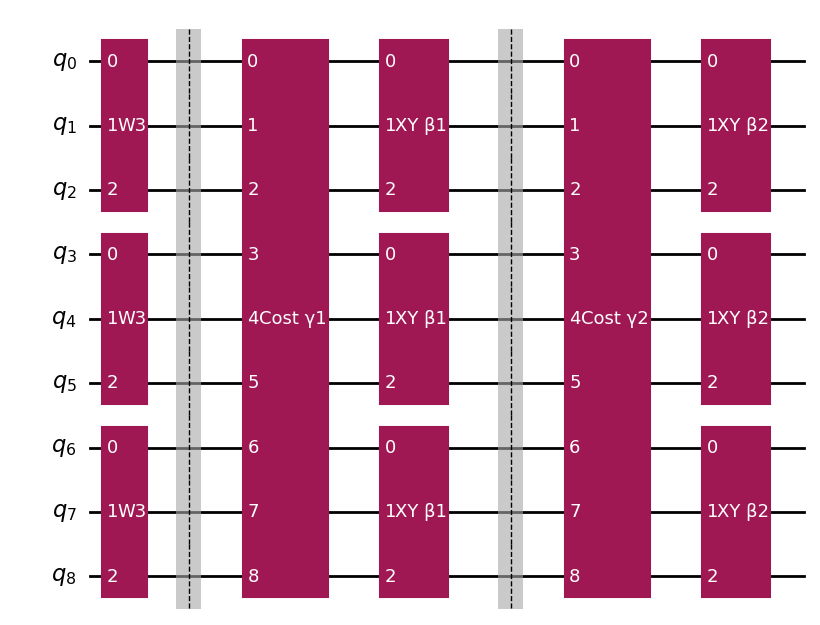

Compact PNG: /content/AgriTrust_MultiFlow_QAOA_results/quantum_circuit_XY_W_QAOA_compact_9q.png
Compact PDF: /content/AgriTrust_MultiFlow_QAOA_results/quantum_circuit_XY_W_QAOA_compact_9q.pdf


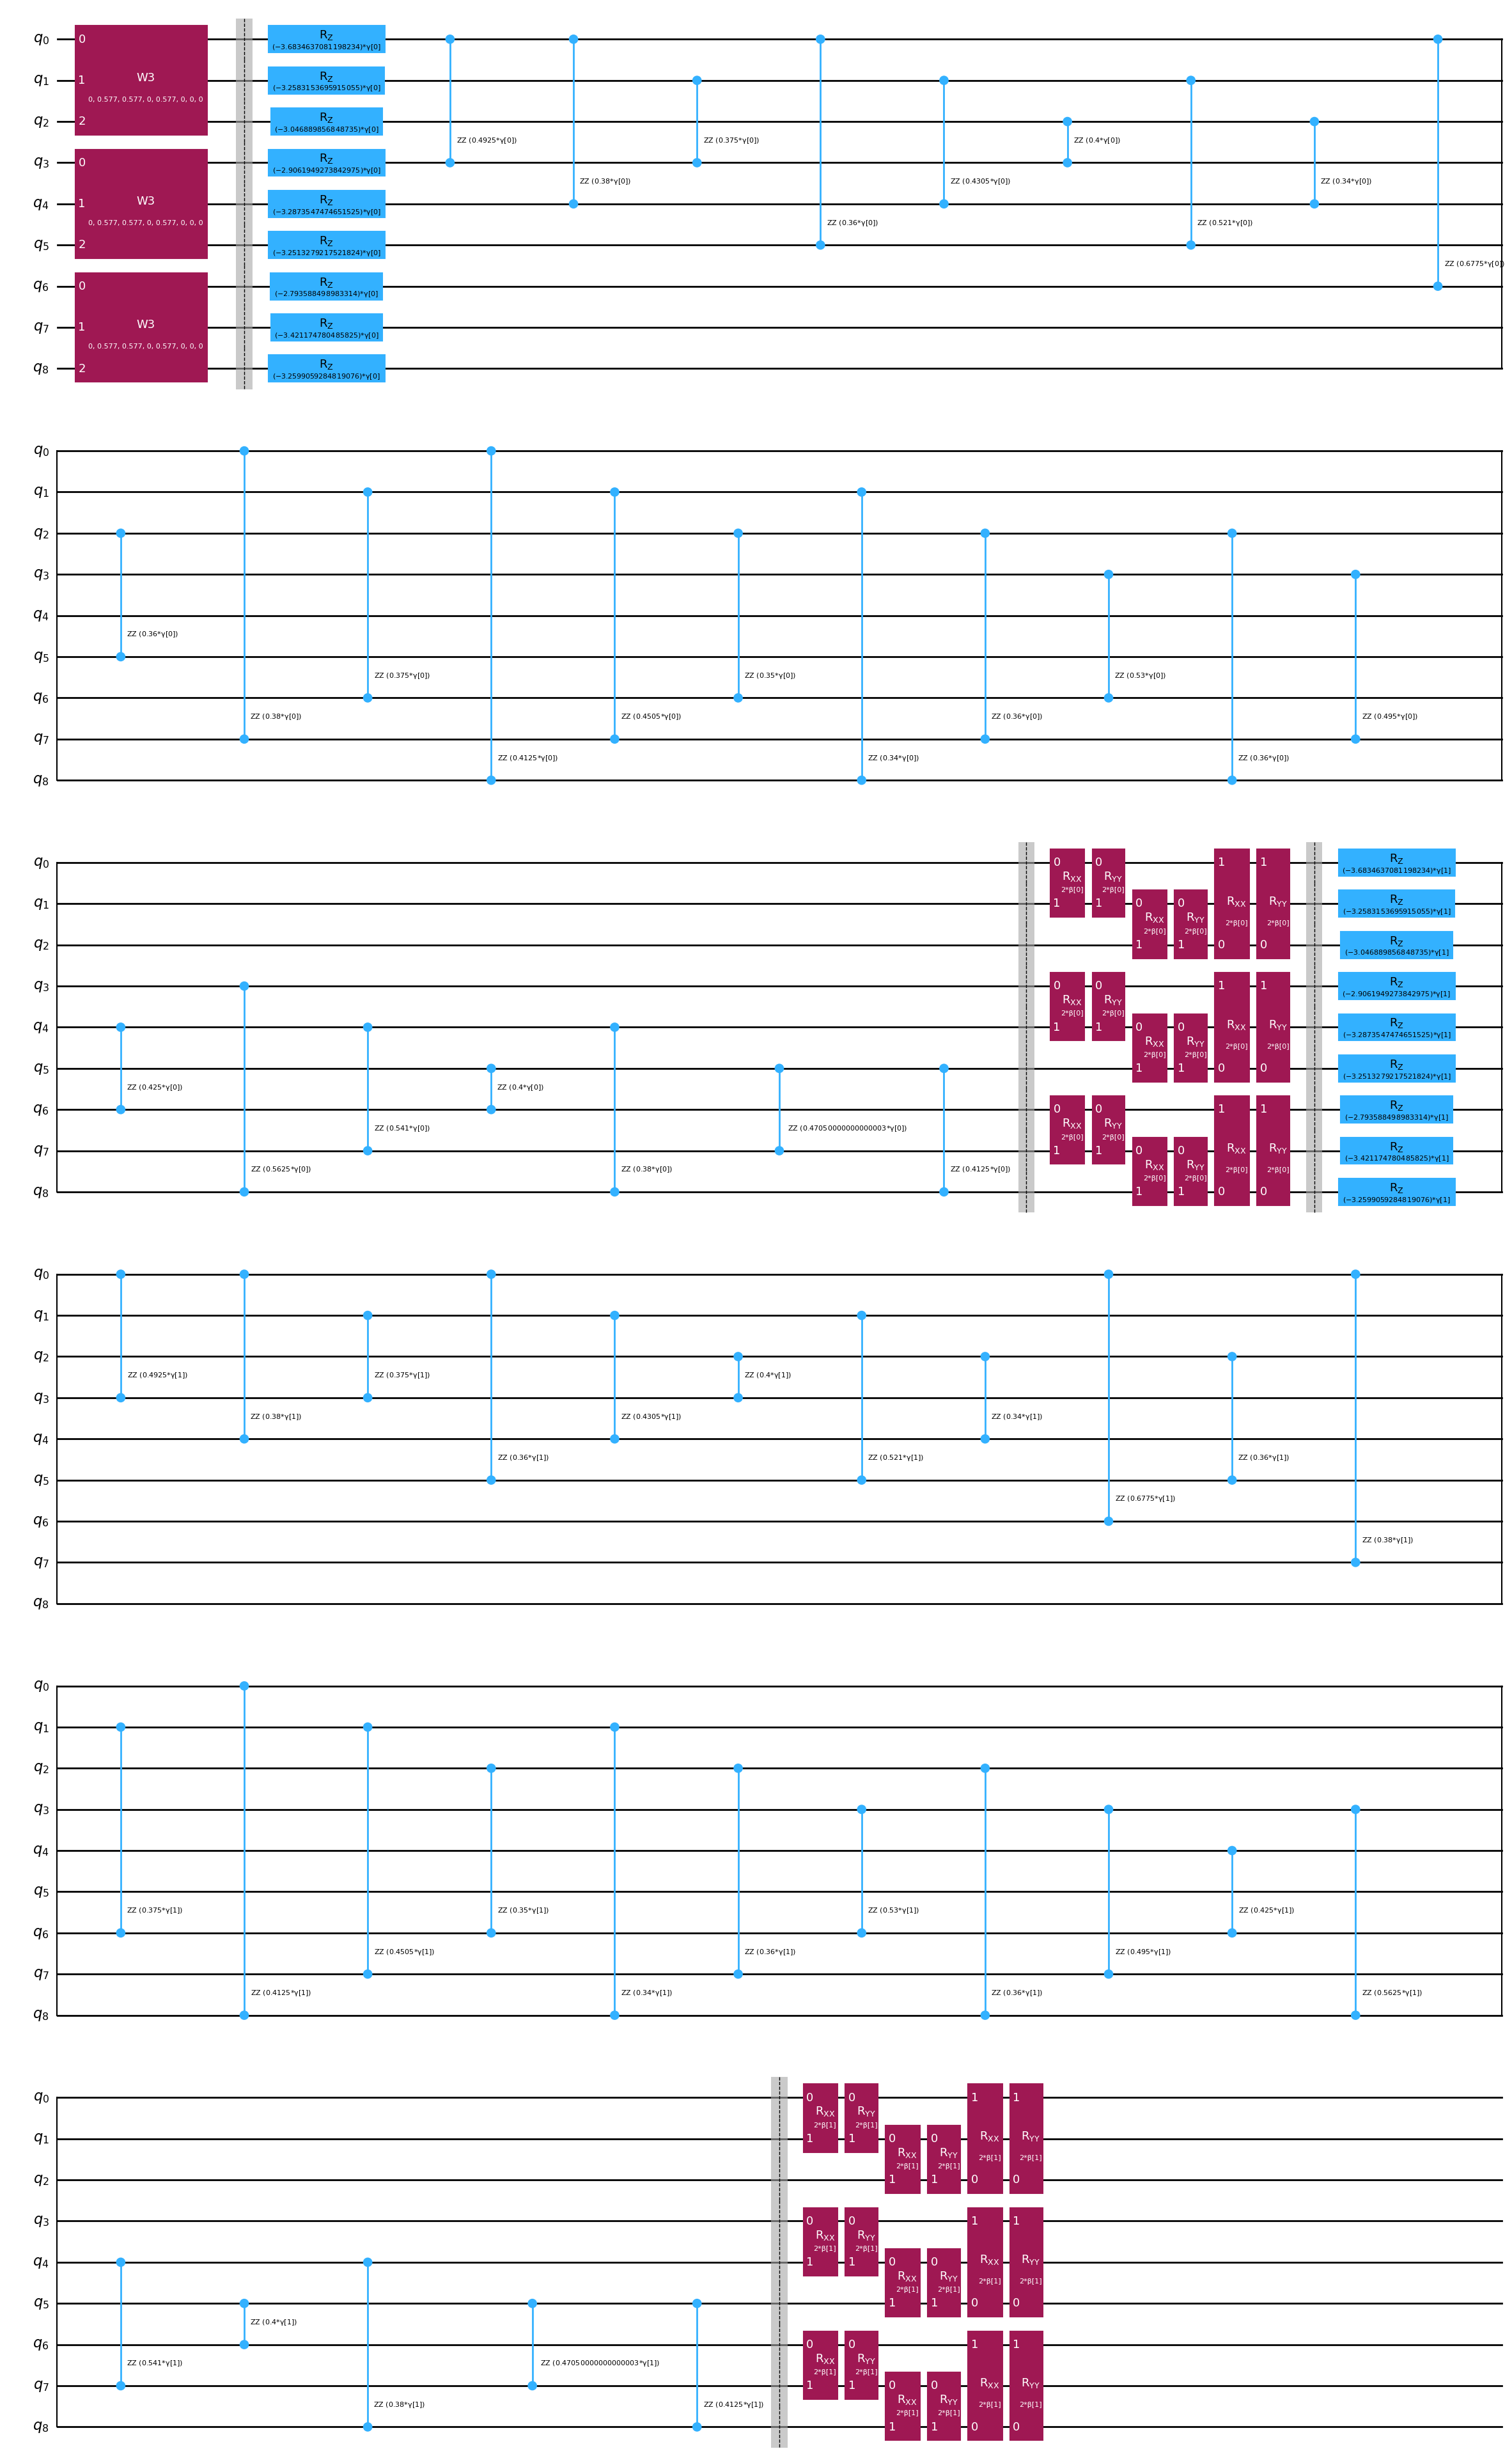

Full PNG: /content/AgriTrust_MultiFlow_QAOA_results/quantum_circuit_XY_W_QAOA_full_9q.png
Full PDF: /content/AgriTrust_MultiFlow_QAOA_results/quantum_circuit_XY_W_QAOA_full_9q.pdf
Full logical depth: 37
Full logical operations: OrderedDict({'rzz': 54, 'rz': 18, 'rxx': 18, 'ryy': 18, 'barrier': 4, 'state_preparation': 3})


In [ ]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
circuit_artifacts = save_quantum_circuit_figures(seed=PAPER_SEEDS[0], output_dir=RESULT_DIR)

display(circuit_artifacts["compact_figure"])
print("Compact PNG:", circuit_artifacts["compact_png"])
print("Compact PDF:", circuit_artifacts["compact_pdf"])

display(circuit_artifacts["full_figure"])
print("Full PNG:", circuit_artifacts["full_png"])
print("Full PDF:", circuit_artifacts["full_pdf"])
print("Full logical depth:", circuit_artifacts["full_ansatz"].depth())
print("Full logical operations:", circuit_artifacts["full_ansatz"].count_ops())


## 6. Main 20-seed 9-qubit experiment — 3 optimizer restarts

Methods:
1. Exact enumeration (ground truth only)
2. Simulated annealing
3. XY-W + CVaR α=0.25
4. Penalty-X + CVaR α=0.25
5. XY-W + expectation
6. Penalty-X + expectation

**Primary gap:** most-probable feasible state vs exact optimum. `best_shot_gap_pct` is retained only as a secondary diagnostic and should not be the headline metric.


In [ ]:
MAIN_9Q_DIR = RESULT_DIR / "main_9q_20seeds_revised"
main_9q_df = run_paper_batch(
    seeds=PAPER_SEEDS,
    configs=[(3, 3)],
    output_dir=MAIN_9Q_DIR,
    run_expectation_ablation_on_9q=True,
    restarts=MAIN_QAOA_RESTARTS,
    qaoa_depth=QAOA_DEPTH,
    cvar_alpha=CVAR_ALPHA,
    penalty_multiplier=PENALTY_MULTIPLIER_PRIMARY,
)
main_9q_df.to_csv(MAIN_9Q_DIR / "main_9q_complete_revised.csv", index=False)
display(main_9q_df.head())


[config 3x3=9q] seed=11
[config 3x3=9q] seed=23
[config 3x3=9q] seed=37
[config 3x3=9q] seed=53
[config 3x3=9q] seed=71
[config 3x3=9q] seed=89
[config 3x3=9q] seed=107
[config 3x3=9q] seed=131
[config 3x3=9q] seed=157
[config 3x3=9q] seed=179
[config 3x3=9q] seed=211
[config 3x3=9q] seed=233
[config 3x3=9q] seed=269
[config 3x3=9q] seed=293
[config 3x3=9q] seed=317
[config 3x3=9q] seed=347
[config 3x3=9q] seed=379
[config 3x3=9q] seed=419
[config 3x3=9q] seed=457
[config 3x3=9q] seed=491


,seed,flows,paths_per_flow,qubits,feasible_combinations,opt_cost,sources,master_energy_min,master_energy_max,master_etx_min,...,shot_feasible_mode_gap_pct,shot_feasible_mode_optimal,best_shot_gap_pct,best_shot_cost,optimizer_fun,optimizer_nfev,optimizer_x_json,penalty_A,heavyhex_physical_qubits,heavyhex_1q
0,11,3,3,9,27,3.413599,"[47, 52, 98]",0.002627,0.003378,4.894896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11,3,3,9,27,3.413599,"[47, 52, 98]",0.002627,0.003378,4.894896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11,3,3,9,27,3.413599,"[47, 52, 98]",0.002627,0.003378,4.894896,...,0.000000,True,0.0,3.413599,3.413599,25.0,"[2.8450114036488254, 1.0641465501302196, 1.365...",0.000000,57.0,808.0
3,11,3,3,9,27,3.413599,"[47, 52, 98]",0.002627,0.003378,4.894896,...,18.767871,False,0.0,3.413599,4.067346,80.0,"[0.06647241340572685, 2.355472662891881, 1.303...",12.172449,57.0,438.0
4,11,3,3,9,27,3.413599,"[47, 52, 98]",0.002627,0.003378,4.894896,...,3.239235,False,0.0,3.413599,3.980130,80.0,"[3.080993400814491, 2.7599471541387013, 1.3167...",0.000000,57.0,808.0


## 7. Penalty-X sensitivity — all 20 seeds

This tests multipliers 1, 2, and 4. Do **not** select a different multiplier per seed. The primary multiplier 2 remains pre-declared; the sensitivity table shows whether the XY-vs-X conclusion is dependent on one arbitrary penalty scale.


In [ ]:
penalty_sensitivity_df = run_penalty_sensitivity_9q(
    seeds=PAPER_SEEDS,
    multipliers=PENALTY_MULTIPLIERS,
    restarts=ABLATION_RESTARTS,
)
penalty_sensitivity_df.to_csv(RESULT_DIR / "penalty_sensitivity_9q_all20.csv", index=False)
penalty_sensitivity_summary = summarize_simple_groups(
    penalty_sensitivity_df,
    group_cols=["penalty_multiplier"],
    metrics=["p_feasible_sv", "p_opt_sv", "gap_pct"],
)
penalty_sensitivity_summary.to_csv(RESULT_DIR / "penalty_sensitivity_9q_summary.csv", index=False)
display(penalty_sensitivity_summary)


[penalty sensitivity] seed=11 A_multiplier=1.0
[penalty sensitivity] seed=11 A_multiplier=2.0
[penalty sensitivity] seed=11 A_multiplier=4.0
[penalty sensitivity] seed=23 A_multiplier=1.0
[penalty sensitivity] seed=23 A_multiplier=2.0
[penalty sensitivity] seed=23 A_multiplier=4.0
[penalty sensitivity] seed=37 A_multiplier=1.0
[penalty sensitivity] seed=37 A_multiplier=2.0
[penalty sensitivity] seed=37 A_multiplier=4.0
[penalty sensitivity] seed=53 A_multiplier=1.0
[penalty sensitivity] seed=53 A_multiplier=2.0
[penalty sensitivity] seed=53 A_multiplier=4.0
[penalty sensitivity] seed=71 A_multiplier=1.0
[penalty sensitivity] seed=71 A_multiplier=2.0
[penalty sensitivity] seed=71 A_multiplier=4.0
[penalty sensitivity] seed=89 A_multiplier=1.0
[penalty sensitivity] seed=89 A_multiplier=2.0
[penalty sensitivity] seed=89 A_multiplier=4.0
[penalty sensitivity] seed=107 A_multiplier=1.0
[penalty sensitivity] seed=107 A_multiplier=2.0
[penalty sensitivity] seed=107 A_multiplier=4.0
[penalty s

,penalty_multiplier,n,p_feasible_sv_mean,p_feasible_sv_ci95_low,p_feasible_sv_ci95_high,p_opt_sv_mean,p_opt_sv_ci95_low,p_opt_sv_ci95_high,gap_pct_mean,gap_pct_ci95_low,gap_pct_ci95_high
0,1.0,20,0.199152,0.157971,0.252713,0.014947,0.008863,0.023247,31.558096,18.081854,45.707816
1,2.0,20,0.213806,0.152107,0.284537,0.012687,0.007612,0.019205,29.935392,17.704472,44.200451
2,4.0,20,0.210971,0.156894,0.274790,0.010973,0.006238,0.017383,34.412733,20.054390,51.208941


## 8. Full 9-qubit depth × objective ablation — all 20 seeds

This is the decisive CVaR test:
- depths: \(p\in\{1,2,3\}\)
- α: 0.10, 0.25, 0.50, 1.00
- α=1.00 = ordinary expectation
- both XY-W and Penalty-X

This cell is computationally longer than the main experiment, but it prevents choosing CVaR or depth after seeing one convenient result.


In [ ]:
ablation_df = run_depth_alpha_ablation_9q(
    seeds=PAPER_SEEDS,
    depths=DEPTH_GRID,
    alphas=CVAR_ALPHA_GRID,
    families=("xy", "x"),
    restarts=ABLATION_RESTARTS,
)
ablation_df.to_csv(RESULT_DIR / "depth_alpha_ablation_9q_all20.csv", index=False)
ablation_summary = summarize_simple_groups(
    ablation_df,
    group_cols=["family", "depth", "alpha", "objective"],
    metrics=["p_feasible_sv", "p_opt_sv", "gap_pct"],
)
ablation_summary.to_csv(RESULT_DIR / "depth_alpha_ablation_9q_summary.csv", index=False)
display(ablation_summary)


[ablation] seed=11 family=xy p=1 alpha=0.1
[ablation] seed=11 family=xy p=1 alpha=0.25
[ablation] seed=11 family=xy p=1 alpha=0.5
[ablation] seed=11 family=xy p=1 alpha=1.0
[ablation] seed=11 family=xy p=2 alpha=0.1
[ablation] seed=11 family=xy p=2 alpha=0.25
[ablation] seed=11 family=xy p=2 alpha=0.5
[ablation] seed=11 family=xy p=2 alpha=1.0
[ablation] seed=11 family=xy p=3 alpha=0.1
[ablation] seed=11 family=xy p=3 alpha=0.25
[ablation] seed=11 family=xy p=3 alpha=0.5
[ablation] seed=11 family=xy p=3 alpha=1.0
[ablation] seed=11 family=x p=1 alpha=0.1
[ablation] seed=11 family=x p=1 alpha=0.25
[ablation] seed=11 family=x p=1 alpha=0.5
[ablation] seed=11 family=x p=1 alpha=1.0
[ablation] seed=11 family=x p=2 alpha=0.1
[ablation] seed=11 family=x p=2 alpha=0.25
[ablation] seed=11 family=x p=2 alpha=0.5
[ablation] seed=11 family=x p=2 alpha=1.0
[ablation] seed=11 family=x p=3 alpha=0.1
[ablation] seed=11 family=x p=3 alpha=0.25
[ablation] seed=11 family=x p=3 alpha=0.5
[ablation] seed=

## 9. Scaling: 12, 16, and 20 qubits — same 20 seeds

Large ideal-statevector runs use one deterministic restart for tractability. This is explicitly recorded in the output. Every size uses the same per-seed master normalization fitted before subsetting.


In [ ]:
SCALING_DIR = RESULT_DIR / "scaling_20seeds_revised"
scaling_df = run_paper_batch(
    seeds=PAPER_SEEDS,
    configs=[(4, 3), (4, 4), (5, 4)],
    output_dir=SCALING_DIR,
    run_expectation_ablation_on_9q=False,
    restarts=SCALING_QAOA_RESTARTS,
    qaoa_depth=QAOA_DEPTH,
    cvar_alpha=CVAR_ALPHA,
    penalty_multiplier=PENALTY_MULTIPLIER_PRIMARY,
)
scaling_df.to_csv(SCALING_DIR / "scaling_complete_revised.csv", index=False)
display(scaling_df.head())


[config 4x3=12q] seed=11
[config 4x3=12q] seed=23
[config 4x3=12q] seed=37
[config 4x3=12q] seed=53
[config 4x3=12q] seed=71
[config 4x3=12q] seed=89
[config 4x3=12q] seed=107
[config 4x3=12q] seed=131
[config 4x3=12q] seed=157
[config 4x3=12q] seed=179
[config 4x3=12q] seed=211
[config 4x3=12q] seed=233
[config 4x3=12q] seed=269
[config 4x3=12q] seed=293
[config 4x3=12q] seed=317
[config 4x3=12q] seed=347
[config 4x3=12q] seed=379
[config 4x3=12q] seed=419
[config 4x3=12q] seed=457
[config 4x3=12q] seed=491
[config 4x4=16q] seed=11
[config 4x4=16q] seed=23
[config 4x4=16q] seed=37
[config 4x4=16q] seed=53
[config 4x4=16q] seed=71
[config 4x4=16q] seed=89
[config 4x4=16q] seed=107
[config 4x4=16q] seed=131
[config 4x4=16q] seed=157
[config 4x4=16q] seed=179
[config 4x4=16q] seed=211
[config 4x4=16q] seed=233
[config 4x4=16q] seed=269
[config 4x4=16q] seed=293
[config 4x4=16q] seed=317
[config 4x4=16q] seed=347
[config 4x4=16q] seed=379
[config 4x4=16q] seed=419
[config 4x4=16q] seed=45

KeyboardInterrupt: 

## 10. Merge results, bootstrap 95% CIs, paired Wilcoxon + Holm correction


In [ ]:
full_df = pd.concat([main_9q_df, scaling_df], ignore_index=True)
full_df.to_csv(RESULT_DIR / "all_20seed_results_revised.csv", index=False)

summary_df = summarize_results(full_df)
summary_df.to_csv(RESULT_DIR / "summary_mean_sd_bootstrap95ci_revised.csv", index=False)
display(summary_df)

paired_tests_df = paired_xy_vs_x_tests(full_df)
paired_tests_df.to_csv(RESULT_DIR / "paired_wilcoxon_holm_xy_vs_x.csv", index=False)
display(paired_tests_df)


## 11. Paper figure — feasibility scaling


In [ ]:
import matplotlib.pyplot as plt

qdf = full_df[full_df["method"].isin(["XY-W-CVaR", "Penalty-X-CVaR"])].copy()
agg = qdf.groupby(["qubits", "method"], as_index=False)["p_feasible_sv"].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
for method, g in agg.groupby("method"):
    ax.plot(g["qubits"], g["p_feasible_sv"], marker="o", label=method)
ax.set_xlabel("Qubits")
ax.set_ylabel("Mean feasible probability")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig_feasibility_vs_qubits_revised.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULT_DIR / "fig_feasibility_vs_qubits_revised.pdf", bbox_inches="tight")
plt.show()


## 12. Paper figure — probability of exact optimum


In [ ]:
agg = qdf.groupby(["qubits", "method"], as_index=False)["p_opt_sv"].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
for method, g in agg.groupby("method"):
    ax.plot(g["qubits"], g["p_opt_sv"], marker="o", label=method)
ax.set_xlabel("Qubits")
ax.set_ylabel("Mean probability of exact optimum")
ax.set_yscale("log")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig_popt_vs_qubits_revised.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULT_DIR / "fig_popt_vs_qubits_revised.pdf", bbox_inches="tight")
plt.show()


## 13. Paper figure — primary optimality gap

This plot uses the **most-probable feasible state gap**. It does not use the best solution found among 2048 shots.


In [ ]:
agg = qdf.groupby(["qubits", "method"], as_index=False)["gap_pct"].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
for method, g in agg.groupby("method"):
    ax.plot(g["qubits"], g["gap_pct"], marker="o", label=method)
ax.set_xlabel("Qubits")
ax.set_ylabel("Mean feasible-mode optimality gap (%)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig_feasible_mode_gap_vs_qubits.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULT_DIR / "fig_feasible_mode_gap_vs_qubits.pdf", bbox_inches="tight")
plt.show()


## 14. Hardware-aware transpilation cost (estimate, not hardware execution)


In [ ]:
hwagg = qdf.groupby(["qubits", "method"], as_index=False)[["heavyhex_depth", "heavyhex_cx"]].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
for method, g in hwagg.groupby("method"):
    ax.plot(g["qubits"], g["heavyhex_depth"], marker="o", label=method)
ax.set_xlabel("Logical qubits")
ax.set_ylabel("Mean heavy-hex transpiled depth")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig_heavyhex_depth_revised.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULT_DIR / "fig_heavyhex_depth_revised.pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for method, g in hwagg.groupby("method"):
    ax.plot(g["qubits"], g["heavyhex_cx"], marker="o", label=method)
ax.set_xlabel("Logical qubits")
ax.set_ylabel("Mean heavy-hex CX count")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig_heavyhex_cx_revised.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULT_DIR / "fig_heavyhex_cx_revised.pdf", bbox_inches="tight")
plt.show()


## 15. 20-seed 9-qubit depolarizing-noise sensitivity

This reuses the exact optimized XY-W-CVaR parameters stored by the main experiment for each seed, then evaluates all pre-declared noise levels. It is **Aer simulation**, not real hardware.


In [ ]:
noise_df = run_noise_batch_9q_from_main_results(
    main_9q_df,
    seeds=PAPER_SEEDS,
    error_levels=NOISE_ERROR_LEVELS,
    shots=NOISE_SHOTS,
)
noise_df.to_csv(RESULT_DIR / "noise_sensitivity_9q_all20.csv", index=False)
noise_summary = summarize_simple_groups(
    noise_df,
    group_cols=["two_qubit_error", "one_qubit_error"],
    metrics=["p_feasible_shots"],
)
noise_summary.to_csv(RESULT_DIR / "noise_sensitivity_9q_summary.csv", index=False)
display(noise_summary)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = noise_summary["two_qubit_error"].to_numpy(dtype=float)
y = noise_summary["p_feasible_shots_mean"].to_numpy(dtype=float)
lo = noise_summary["p_feasible_shots_ci95_low"].to_numpy(dtype=float)
hi = noise_summary["p_feasible_shots_ci95_high"].to_numpy(dtype=float)
ax.plot(x, y, marker="o")
ax.fill_between(x, lo, hi, alpha=0.2)
ax.set_xlabel("Two-qubit depolarizing error probability")
ax.set_ylabel("Mean feasible-shot fraction")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig_noise_feasibility_9q_all20.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULT_DIR / "fig_noise_feasibility_9q_all20.pdf", bbox_inches="tight")
plt.show()


## 16. Reproducibility manifest


In [ ]:
manifest = {
    "paper_seeds": PAPER_SEEDS,
    "n_sensor_nodes": N_SENSOR_NODES,
    "communication_range": COMMUNICATION_RANGE,
    "interference_range": INTERFERENCE_RANGE,
    "route_weights": ROUTE_WEIGHTS,
    "lambda_interference": LAMBDA_INTERFERENCE,
    "lambda_congestion": LAMBDA_CONGESTION,
    "primary_qaoa_depth": QAOA_DEPTH,
    "primary_cvar_alpha": CVAR_ALPHA,
    "optimizer": "COBYLA",
    "optimizer_maxiter": OPT_MAXITER,
    "main_9q_restarts": MAIN_QAOA_RESTARTS,
    "scaling_restarts": SCALING_QAOA_RESTARTS,
    "ablation_restarts": ABLATION_RESTARTS,
    "primary_penalty_multiplier": PENALTY_MULTIPLIER_PRIMARY,
    "penalty_multiplier_sensitivity": list(PENALTY_MULTIPLIERS),
    "depth_ablation": list(DEPTH_GRID),
    "alpha_ablation": list(CVAR_ALPHA_GRID),
    "final_shots": FINAL_SHOTS,
    "noise_shots": NOISE_SHOTS,
    "noise_error_levels": list(NOISE_ERROR_LEVELS),
    "scaling_configs": SCALING_CONFIGS,
    "normalization": "fixed per-seed full 5-flow x 5-path master set",
    "primary_gap_metric": "most-probable feasible state gap from ideal statevector",
    "qiskit": qiskit.__version__,
    "qiskit_aer": qiskit_aer.__version__,
    "optimization_backend": "Aer ideal statevector",
    "finite_shot_evaluation": True,
    "hardware_execution": False,
    "primary_security_claim": False,
    "risk_weight_primary": ROUTE_WEIGHTS["risk"],
}
with open(RESULT_DIR / "reproducibility_manifest_revised.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))


## 17. What the paper may claim after the corrected rerun

Report only what the new 20-seed outputs support.

**Safe primary questions:**
1. Does XY-W preserve one-hot feasibility while Penalty-X loses feasible probability as the encoded problem grows?
2. Does XY-W place more probability on exact/near-optimal feasible route combinations?
3. Does CVaR outperform expectation for any consistent depth/α regime, or is the result mixed?
4. Is the feasibility/solution-quality benefit accompanied by increased transpiled depth and CX count?
5. How rapidly does feasibility degrade under the stated depolarizing-noise model across all 20 seeds?

**Do not claim:** quantum advantage, speedup over exact/SA, real-device performance, CVaR superiority unless the ablation supports it, attack-detection F1≈1, or security from PDR.
